# E5 — Acelerador: CPU vs Hailo-10H

## Pregunta de investigación

¿Qué ventajas proporciona la aceleración por hardware Hailo-10H?

## Hipótesis previa

Hailo-10H debería proporcionar speedup significativo en throughput.

## Configuración del experimento

| Parámetro | Valores |
|-----------|---------|
| Acelerador | CPU (False) vs Hailo-10H (True) |
| Modelos | Modelo optimizado para Hailo |
| Total | Pares CPU/Hailo |

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms.collection import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Carga de datos (E5) ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "TFG-DATA" / "E5"

_EMPTY_COLS = ["run_id", "model_label", "engine", "test_type", "batch_size",
               "context_size", "fan", "accelerator", "tokens_per_s_mean",
               "words_per_s_mean", "latency_ms_mean", "ttft_ms_mean",
               "perplexity_geomean", "temp_max_c", "temp_mean_c",
               "power_mean_w", "power_max_w", "throttled_ratio",
               "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
               "n_empty_generations", "mbu_pct", "model_size_gb"]

if not DATA_ROOT.is_dir():
    print(f"AVISO: No encontrado directorio E5: {DATA_ROOT.resolve()}")
    coll = RunCollection(runs=[])
    summary = pd.DataFrame(columns=_EMPTY_COLS)
    hw_full = pd.DataFrame()
    pm_full = pd.DataFrame()
    ex = pd.DataFrame(columns=_EMPTY_COLS)
    fom_red_df = pd.DataFrame()
else:
    coll = load_collection(DATA_ROOT)
    print(f"Runs cargados E5: {len(coll)}")

    summary = coll.summary_df()
    hw_full  = coll.hw_metrics_df()
    pm_full  = coll.prompt_metrics_df()

    ex = summary[summary["test_type"] == "TYPE_1"].copy()
    # model_base: strip engine suffix (L)/(O)/(H) para emparejar CPU↔Hailo
    ex["model_base"] = (
        ex["model_label"]
        .str.replace(r'\s*\([LOH]\)\s*', '', regex=True)
        .str.strip()
    )

    _accels = sorted(bool(a) for a in ex["accelerator"].unique())
    print(f"Runs en E5: {ex.shape[0]}  |  Aceleradores: {_accels}")

    # --- FoM_red = sqrt(T_norm · ε_norm), anclaje CPU del mismo modelo ---
    # N se cancela: T_norm = tok/s_H/tok/s_C, ε_norm = (J/tok)_C/(J/tok)_H
    _cpu_ex   = ex[~ex["accelerator"]].set_index("model_base")
    _hailo_ex = ex[ex["accelerator"]].set_index("model_base")
    _models_paired = sorted(set(_cpu_ex.index) & set(_hailo_ex.index))

    _rows = []
    for _m in _models_paired:
        _c = _cpu_ex.loc[_m]
        _h = _hailo_ex.loc[_m]
        T_cpu    = float(_c["tokens_per_s_mean"])
        T_h      = float(_h["tokens_per_s_mean"])
        J_cpu    = float(_c["energy_per_token_j"])
        J_h      = float(_h["energy_per_token_j"])
        T_norm   = T_h / T_cpu
        eps_norm = J_cpu / J_h
        fom_red  = float(np.sqrt(T_norm * eps_norm))
        _rows.append({
            "model_base": _m,
            "tok/s CPU": T_cpu, "tok/s Hailo": T_h,    "T_norm": T_norm,
            "J/tok CPU": J_cpu, "J/tok Hailo": J_h,    "ε_norm": eps_norm,
            "FoM_red": fom_red,
        })
    fom_red_df = pd.DataFrame(_rows)

    # Usabilidad: T_hum desde velocidad mínima de lectura (3 pal/s)
    if not pm_full.empty:
        from monitorviz.transforms.fom import compute_usability
        ex, _ = compute_usability(ex, pm_full)
    else:
        ex["T_hum"] = np.nan
        ex["usable"] = False

    if fom_red_df.empty:
        print("AVISO: sin pares CPU↔Hailo — añade los runs Hailo al submodulo de datos")
    else:
        print(fom_red_df.round(3))

tokenProb is not valid JSON for run=1780932981355222737 prompt=0: Expecting value: line 1 column 1 (char 0)
tokenProb size mismatch in run=1780932981355222737 prompt=0: got 0 tokens, eval_count=512
tokenProb is not valid JSON for run=1780932981355222737 prompt=1: Expecting value: line 1 column 1 (char 0)
tokenProb size mismatch in run=1780932981355222737 prompt=1: got 0 tokens, eval_count=512
tokenProb is not valid JSON for run=1780932981355222737 prompt=2: Expecting value: line 1 column 1 (char 0)
tokenProb size mismatch in run=1780932981355222737 prompt=2: got 0 tokens, eval_count=512
tokenProb is not valid JSON for run=1780932981355222737 prompt=3: Expecting value: line 1 column 1 (char 0)
tokenProb size mismatch in run=1780932981355222737 prompt=3: got 0 tokens, eval_count=180
tokenProb is not valid JSON for run=1780932981355222737 prompt=4: Expecting value: line 1 column 1 (char 0)
tokenProb size mismatch in run=1780932981355222737 prompt=4: got 0 tokens, eval_count=231
tokenProb 

Runs cargados E5: 5
Runs en E5: 5  |  Aceleradores: [False, True]
         model_base  tok/s CPU  tok/s Hailo  T_norm  J/tok CPU  J/tok Hailo  ε_norm  FoM_red
0  DeepSeek-R1-1.5B     10.253        6.783   0.662      0.701        1.114   0.629    0.645
1      Llama-3.2-3B      5.025        2.653   0.528      1.385        1.061   1.304    0.830


## Resumen ejecutivo
> TODO: Actualizar con resultados finales.

# 📊 Figuras y tablas de la memoria

In [26]:
# Tabla maestra E5 — CPU vs Hailo por modelo
# T_norm = tok/s_Hailo / tok/s_CPU  |  ε_norm = J/tok_CPU / J/tok_Hailo
# FoM_red = sqrt(T_norm · ε_norm)   [N se cancela al ser el mismo modelo]
if not fom_red_df.empty:
    _disp = fom_red_df.copy()
    _disp.columns = [
        "Modelo", "tok/s CPU", "tok/s Hailo", "T_norm",
        "J/tok CPU", "J/tok Hailo", "ε_norm", "FoM_red",
    ]

    # Usable: Hailo supera T_hum?
    _t_hum_map = (
        ex[~ex["accelerator"] & ex["T_hum"].notna()]
        .set_index("model_base")["T_hum"]
        if "T_hum" in ex.columns else pd.Series(dtype=float)
    )
    _usable_hailo = []
    for _, row in fom_red_df.iterrows():
        _t_hum_ref = _t_hum_map.get(row["model_base"], np.nan)
        _usable_hailo.append(
            "✓" if (not np.isnan(_t_hum_ref) and row["tok/s Hailo"] >= _t_hum_ref) else "✗"
        )
    _disp["Usable (H)"] = _usable_hailo
    _disp["Usable (C)"] = [
        "✓" if (not np.isnan(_t_hum_map.get(r["model_base"], np.nan))
                and r["tok/s CPU"] >= _t_hum_map.get(r["model_base"], np.nan))
        else "✗"
        for _, r in fom_red_df.iterrows()
    ]

    display(_disp.round(3))
    print("\nNota: FoM_red > 1 → Hailo tiene mejor balance rendimiento/energía que CPU")
else:
    print("Sin datos para tabla comparativa")

,Modelo,tok/s CPU,tok/s Hailo,T_norm,J/tok CPU,J/tok Hailo,ε_norm,FoM_red,Usable (H),Usable (C)
0,DeepSeek-R1-1.5B,10.253,6.783,0.662,0.701,1.114,0.629,0.645,✓,✓
1,Llama-3.2-3B,5.025,2.653,0.528,1.385,1.061,1.304,0.830,✗,✓



Nota: FoM_red > 1 → Hailo tiene mejor balance rendimiento/energía que CPU


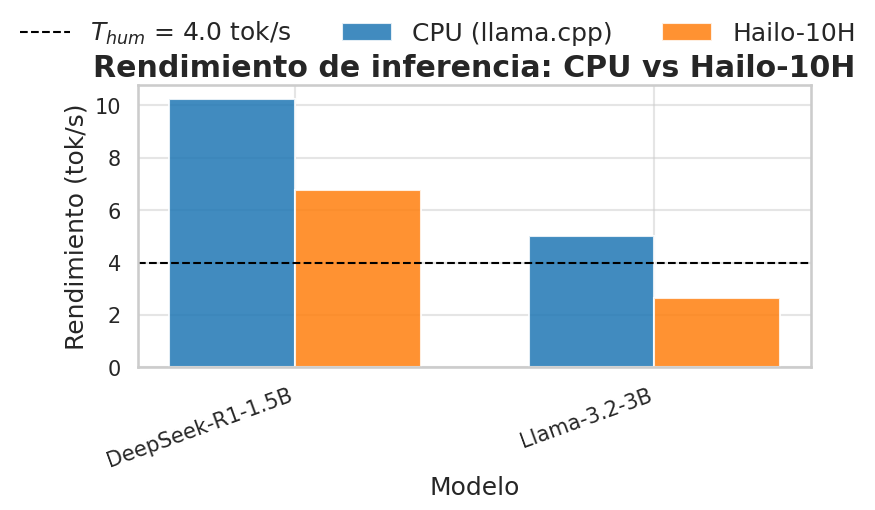

In [3]:
# Fig 1 — Rendimiento: tok/s CPU vs Hailo con umbral de usabilidad T_hum
if not fom_red_df.empty:
    _models1 = fom_red_df["model_base"].tolist()
    _x1 = np.arange(len(_models1))
    _w1 = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(_x1 - _w1/2, fom_red_df["tok/s CPU"],   _w1,
           label="CPU (llama.cpp)", color="tab:blue",   alpha=0.85)
    ax.bar(_x1 + _w1/2, fom_red_df["tok/s Hailo"], _w1,
           label="Hailo-10H",       color="tab:orange", alpha=0.85)

    # Línea T_hum — media de los runs CPU con T_hum disponible
    _t_hum_vals1 = ex[~ex["accelerator"] & ex["T_hum"].notna()]["T_hum"]
    if not _t_hum_vals1.empty:
        _t_hum1 = float(_t_hum_vals1.mean())
        ax.axhline(_t_hum1, ls="--", color="black", lw=1.5,
                   label=f"$T_{{hum}}$ = {_t_hum1:.1f} tok/s")

    ax.set_xticks(_x1)
    ax.set_xticklabels(_models1, rotation=20, ha='right')
    ax.set_ylabel("Rendimiento (tok/s)")
    ax.set_xlabel("Modelo")
    ax.set_title("Rendimiento de inferencia: CPU vs Hailo-10H")
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos")

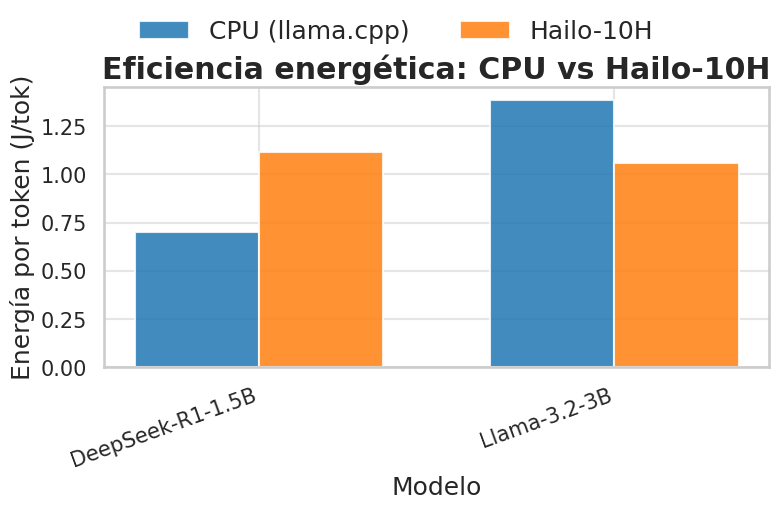

In [27]:
# Fig 2 — Eficiencia energética: J/tok CPU vs Hailo
if not fom_red_df.empty:
    _models2 = fom_red_df["model_base"].tolist()
    _x2 = np.arange(len(_models2))
    _w2 = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(_x2 - _w2/2, fom_red_df["J/tok CPU"],   _w2,
           label="CPU (llama.cpp)", color="tab:blue",   alpha=0.85)
    ax.bar(_x2 + _w2/2, fom_red_df["J/tok Hailo"], _w2,
           label="Hailo-10H",       color="tab:orange", alpha=0.85)
    ax.set_xticks(_x2)
    ax.set_xticklabels(_models2, rotation=20, ha='right')
    ax.set_ylabel("Energía por token (J/tok)")
    ax.set_xlabel("Modelo")
    ax.set_title("Eficiencia energética: CPU vs Hailo-10H")
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos")

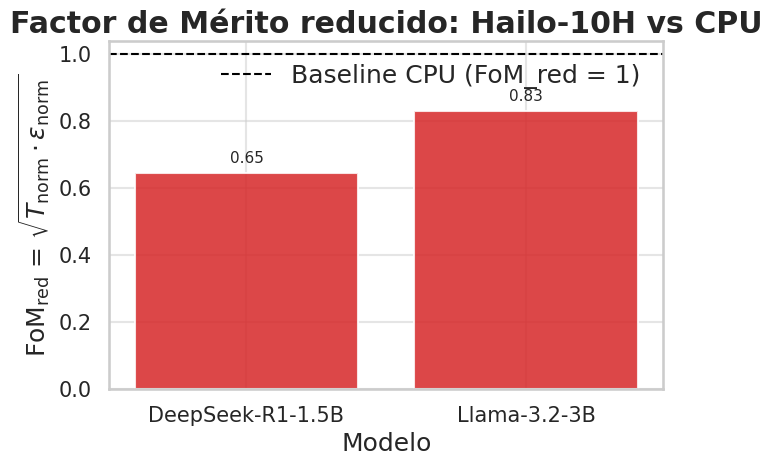

Verde: Hailo mejora el balance rendimiento/energía respecto a CPU
Rojo:  CPU tiene mejor balance rendimiento/energía


In [28]:
# Fig 3 — FoM_red por modelo (verde > 1 = Hailo mejor balance, rojo < 1 = CPU mejor)
if not fom_red_df.empty:
    _models3  = fom_red_df["model_base"].tolist()
    _fom_vals = fom_red_df["FoM_red"].tolist()
    _colors3  = ["tab:green" if v >= 1.0 else "tab:red" for v in _fom_vals]

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(_models3, _fom_vals, color=_colors3, alpha=0.85)
    ax.axhline(1.0, ls="--", color="black", lw=1.5, label="Baseline CPU (FoM_red = 1)")
    for bar, v in zip(bars, _fom_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=11)
    ax.set_ylabel(r"FoM$_\mathrm{red}$ = $\sqrt{T_\mathrm{norm}\cdot\varepsilon_\mathrm{norm}}$")
    ax.set_xlabel("Modelo")
    ax.set_title("Factor de Mérito reducido: Hailo-10H vs CPU")
    ax.set_ylim(0, max(_fom_vals) * 1.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
    print("Verde: Hailo mejora el balance rendimiento/energía respecto a CPU")
    print("Rojo:  CPU tiene mejor balance rendimiento/energía")
else:
    print("Sin datos")

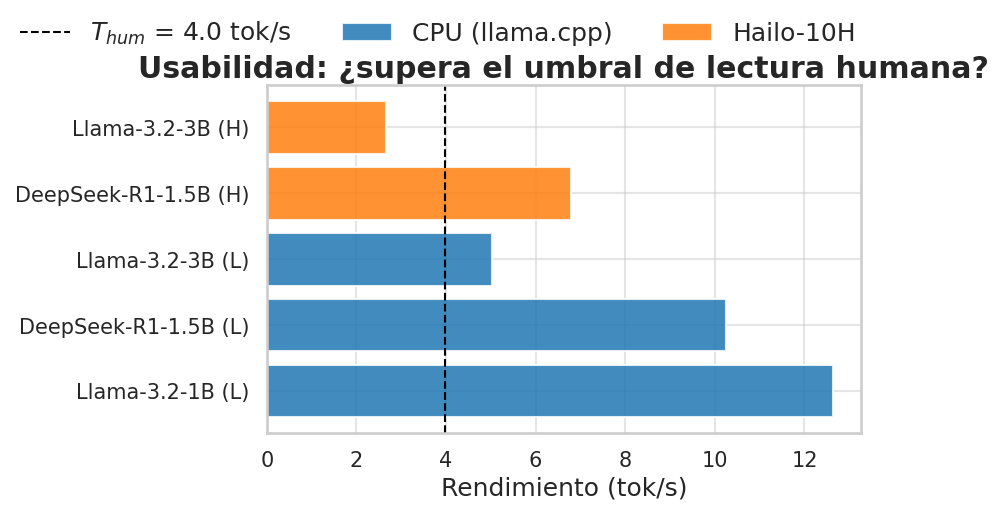

In [29]:
# Fig 4 — Usabilidad: tok/s CPU vs Hailo con umbral T_hum
if not ex.empty:
    _cpu_ex4   = ex[~ex["accelerator"]].copy()
    _hailo_ex4 = ex[ex["accelerator"]].copy()

    # Ordenar por tok/s CPU descendente
    _order4 = (
        _cpu_ex4.sort_values("tokens_per_s_mean", ascending=False)["model_label"].tolist()
        + _hailo_ex4.sort_values("tokens_per_s_mean", ascending=False)["model_label"].tolist()
    )
    _all4 = pd.concat([_cpu_ex4, _hailo_ex4])

    _palette4 = {False: "tab:blue", True: "tab:orange"}
    _labels4  = {False: "CPU (llama.cpp)", True: "Hailo-10H"}

    fig, ax = plt.subplots(figsize=(9, 5))
    for _acc, _grp in _all4.groupby("accelerator"):
        ax.barh(
            _grp["model_label"],
            _grp["tokens_per_s_mean"],
            color=_palette4[_acc], alpha=0.85, label=_labels4[_acc],
        )

    # Umbral T_hum
    _t_hum_vals4 = ex[~ex["accelerator"] & ex["T_hum"].notna()]["T_hum"]
    if not _t_hum_vals4.empty:
        _t_hum4 = float(_t_hum_vals4.mean())
        ax.axvline(_t_hum4, ls="--", color="black", lw=1.5,
                   label=f"$T_{{hum}}$ = {_t_hum4:.1f} tok/s")

    ax.set_xlabel("Rendimiento (tok/s)")
    ax.set_title("Usabilidad: ¿supera el umbral de lectura humana?")
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos")

# 📎 ANEXO

In [7]:
# Tabla comparativa — métricas de inferencia y hardware
display_cols = [
    "model_label", "engine",
    "tokens_per_s_mean", "words_per_s_mean",
    "latency_ms_mean", "ttft_ms_mean",
    "perplexity_geomean",
]
cols = [c for c in display_cols if c in ex.columns]
if not ex.empty:
    display(ex[cols].round(3))
else:
    print("Sin datos")

# Segunda tabla: eficiencia
eff_cols = [
    "model_label", "engine",
    "temp_max_c", "temp_mean_c",
    "power_mean_w", "power_max_w",
    "throttled_ratio",
    "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
]
eff_cols = [c for c in eff_cols if c in ex.columns]
if not ex.empty and eff_cols:
    display(ex[eff_cols].round(3))

,model_label,engine,tokens_per_s_mean,words_per_s_mean,latency_ms_mean,ttft_ms_mean,perplexity_geomean
0,Llama-3.2-1B (L),LLAMA,12.629,9.802,80206.470,643.654,2.776
1,DeepSeek-R1-1.5B (L),LLAMA,10.253,8.371,172295.632,927.864,3.361
2,Llama-3.2-3B (L),LLAMA,5.025,3.667,215850.674,1836.759,2.376
3,DeepSeek-R1-1.5B (H),HAILO_OLLAMA,6.783,5.421,63355.990,0.000,NaN
4,Llama-3.2-3B (H),HAILO_OLLAMA,2.653,1.985,170278.631,0.000,NaN


,model_label,engine,temp_max_c,temp_mean_c,power_mean_w,power_max_w,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
0,Llama-3.2-1B (L),LLAMA,69.95,67.299,6.889,9.456,0.0,0.545,4677.059,0.962
1,DeepSeek-R1-1.5B (L),LLAMA,74.35,70.528,7.188,9.488,0.0,0.701,10051.552,0.967
2,Llama-3.2-3B (L),LLAMA,69.40,65.916,6.958,9.371,0.0,1.385,12793.248,0.979
3,DeepSeek-R1-1.5B (H),HAILO_OLLAMA,50.15,48.471,2.007,6.000,0.0,1.114,14.894,0.004
4,Llama-3.2-3B (H),HAILO_OLLAMA,50.70,48.735,2.014,6.000,0.0,1.061,36.855,0.004


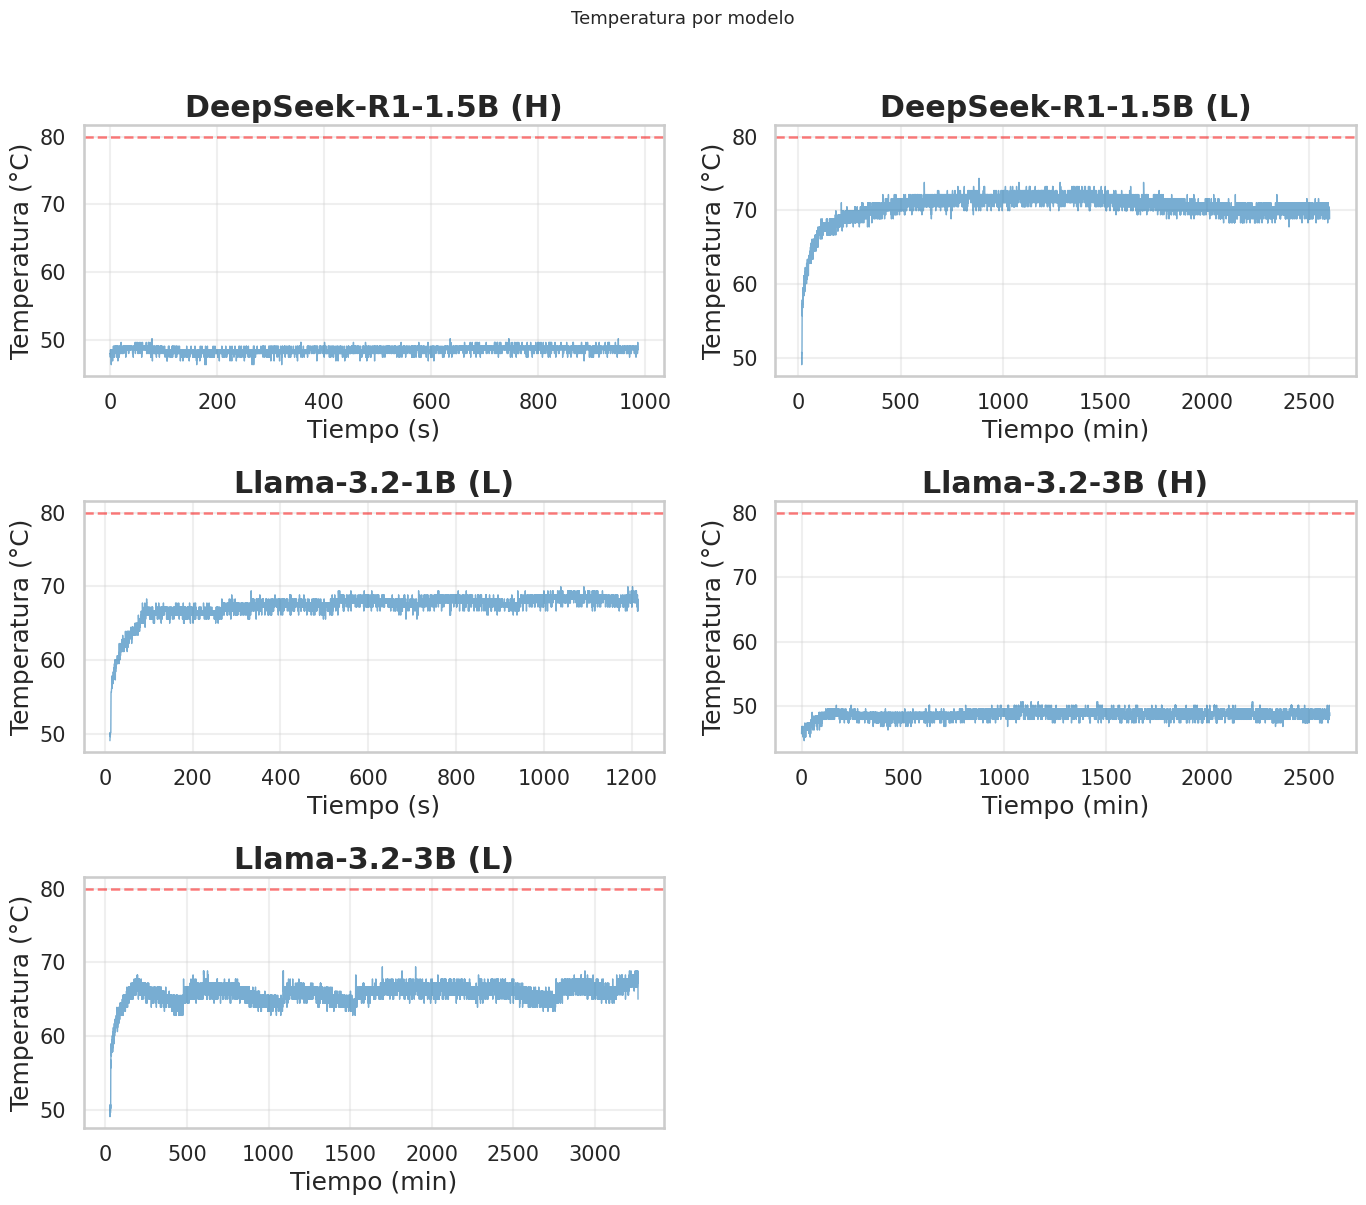

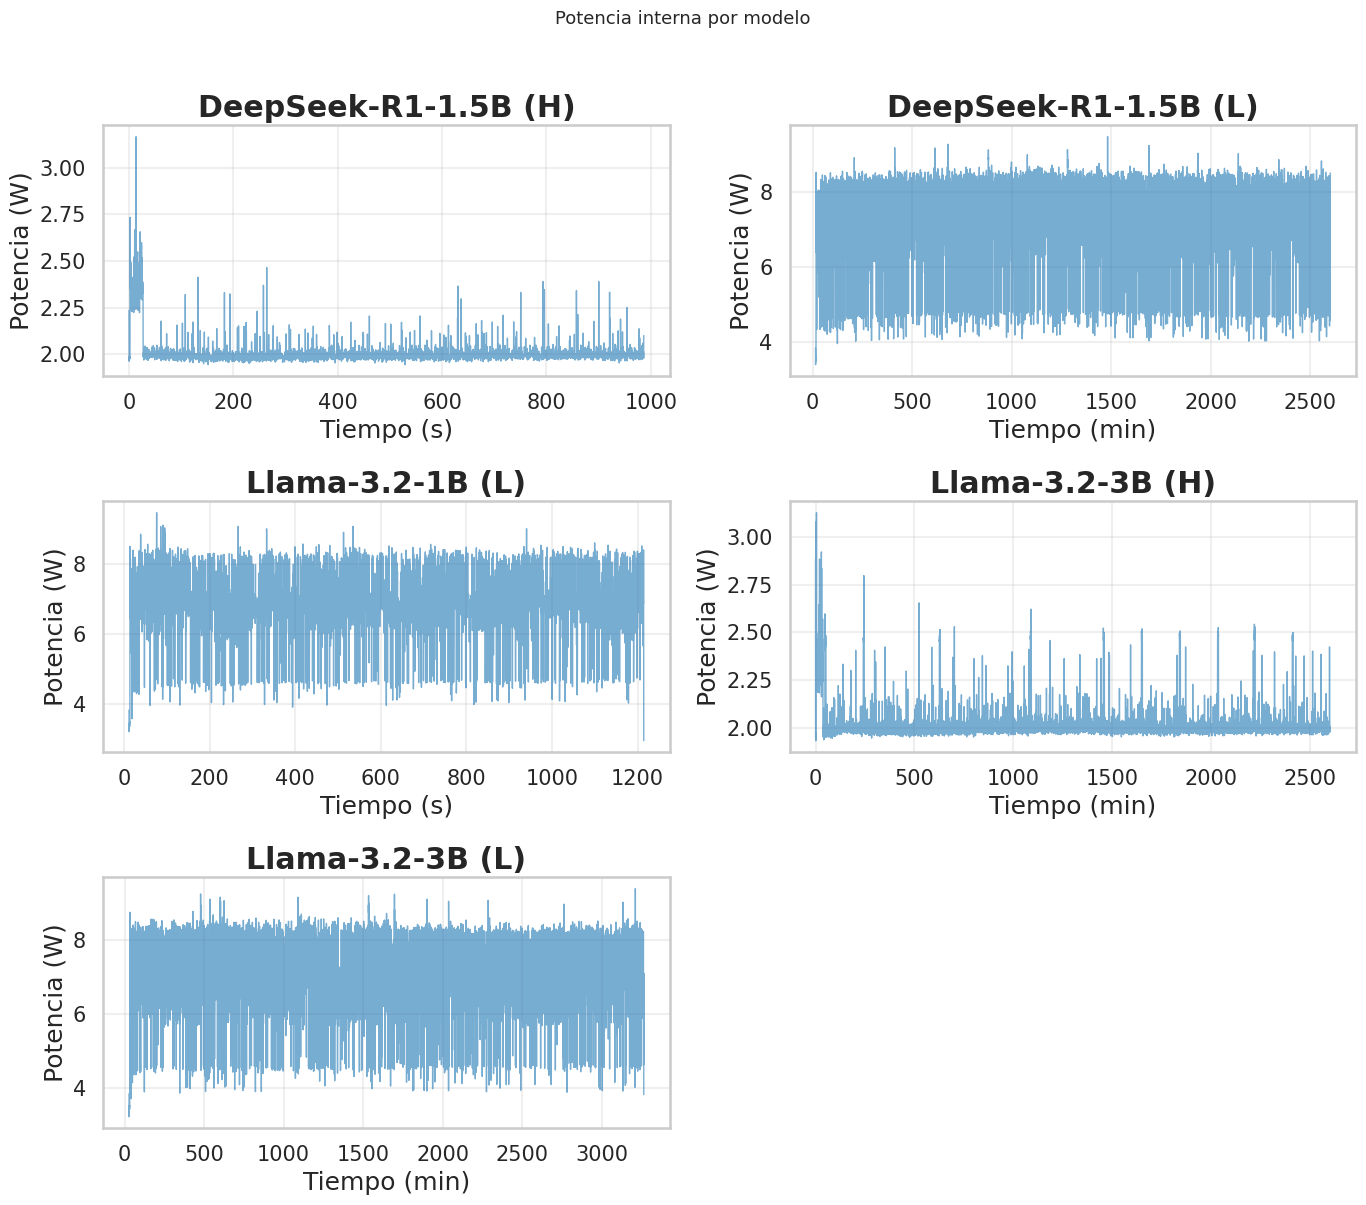

In [8]:
# Timelines de temperatura y potencia (small multiples, 2 columnas)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

def _plot_timeline(hw_ex, models, y_col, ylabel, suptitle, hline=None):
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        # Plot each run separately (fast matplotlib lines, no seaborn aggregation)
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub[y_col].values, alpha=0.6, linewidth=1)
        if hline is not None:
            ax.axhline(hline, ls="--", color="red", alpha=0.5)
        total_s = hw_m["t_rel_s"].max()
        ax.set_xlabel("Tiempo (min)" if total_s > 1800 else "Tiempo (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    _plot_timeline(hw_ex, models, "temperature_c", "Temperatura (°C)",
                   "Temperatura por modelo", hline=80)
    _plot_timeline(hw_ex, models, "internal_power_w", "Potencia (W)",
                   "Potencia interna por modelo")
else:
    print("Sin datos de hardware para timelines")

/tmp/ipykernel_312121/98568102.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_312121/98568102.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


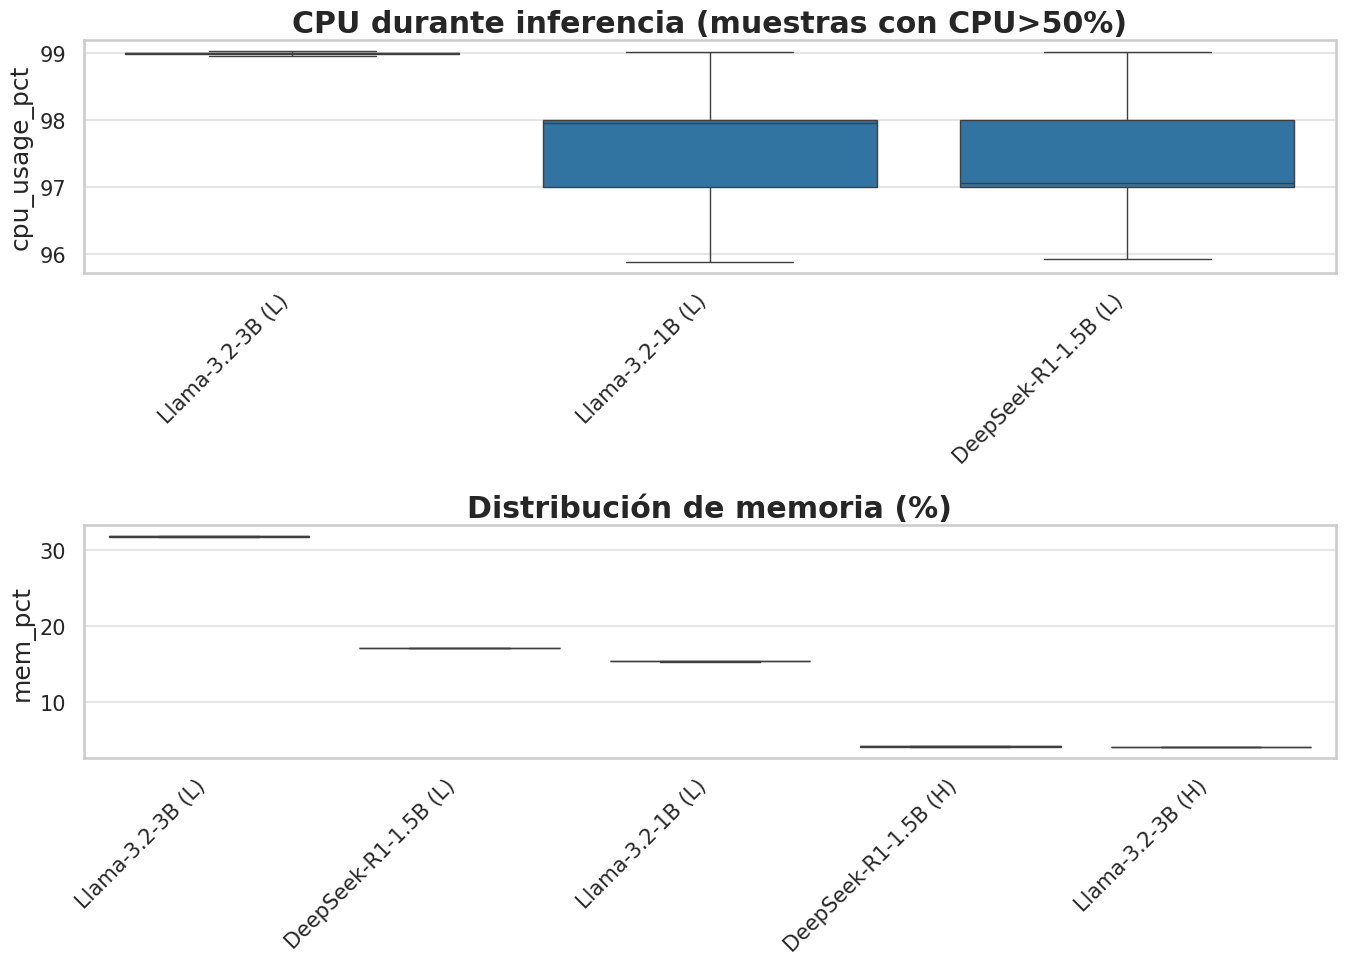

/tmp/ipykernel_312121/98568102.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_312121/98568102.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


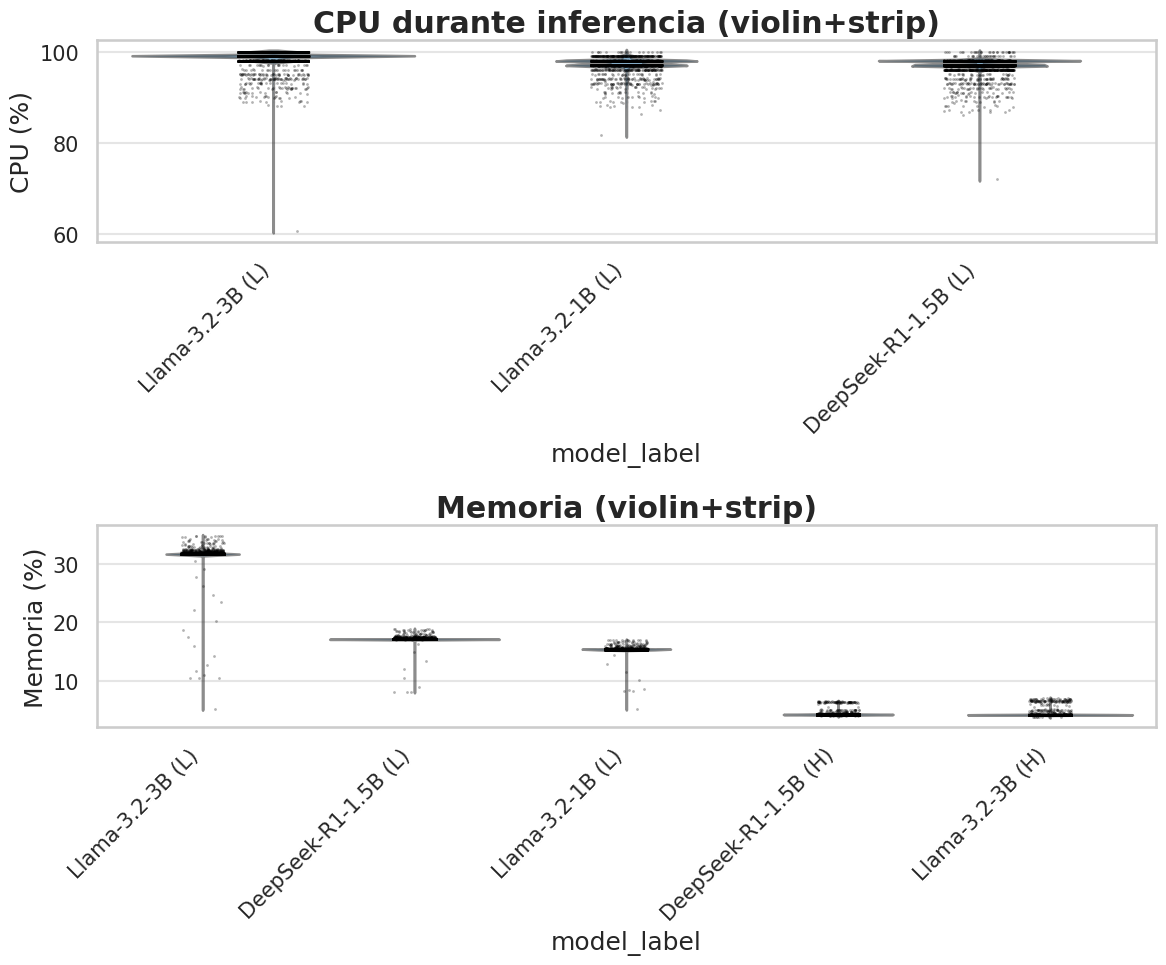

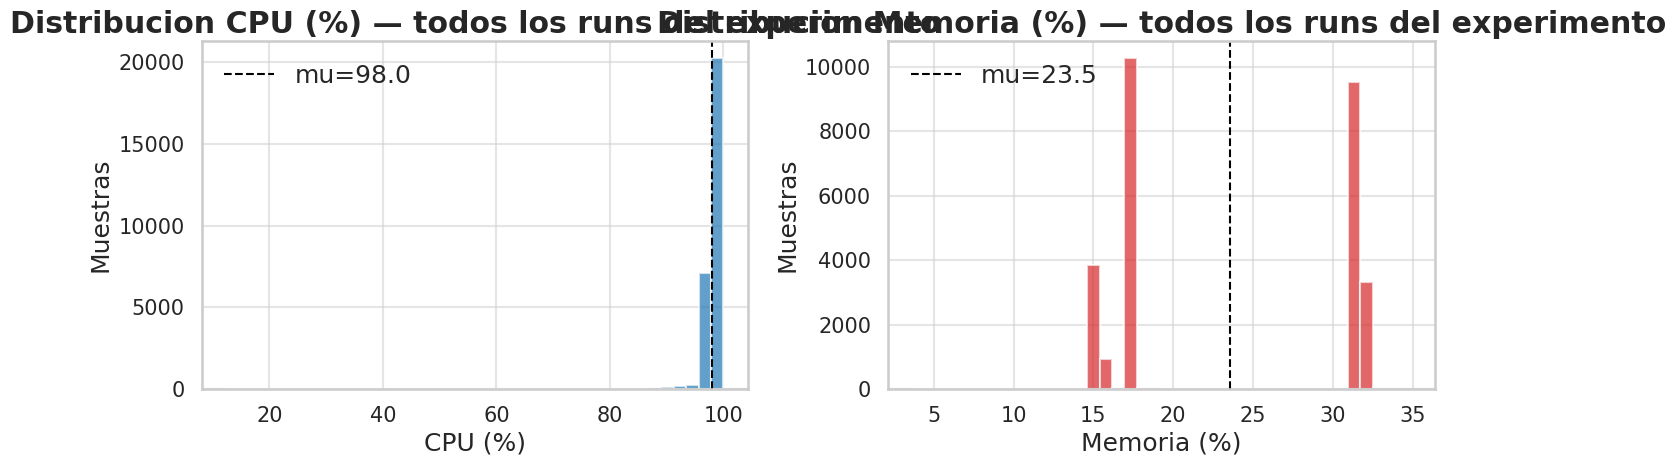

In [9]:
# Sección 5a — Boxplot CPU y Memoria
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=active, x="model_label", y="cpu_usage_pct",
                order=order_cpu, showfliers=False, ax=axes[0])
    axes[0].set_title("CPU durante inferencia (muestras con CPU>50%)")
    axes[0].set_xlabel("")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=hw_ex, x="model_label", y="mem_pct",
                order=order_mem, showfliers=False, ax=axes[1])
    axes[1].set_title("Distribución de memoria (%)")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    plt.show()

    # Sección 5b — Violin + strip
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index
                 if not active.empty else [])
    if len(order_cpu) > 0:
        sns.violinplot(data=active, x="model_label", y="cpu_usage_pct",
                       order=order_cpu, inner=None, alpha=0.6, ax=axes[0])
        sns.stripplot(data=active, x="model_label", y="cpu_usage_pct",
                      order=order_cpu, size=2, alpha=0.3, color="black", ax=axes[0])
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_title("CPU durante inferencia (violin+strip)")
        axes[0].set_ylabel("CPU (%)")
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index)
    sns.violinplot(data=hw_ex, x="model_label", y="mem_pct",
                   order=order_mem, inner=None, alpha=0.6, ax=axes[1])
    sns.stripplot(data=hw_ex, x="model_label", y="mem_pct",
                  order=order_mem, size=2, alpha=0.3, color="black", ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_title("Memoria (violin+strip)")
    axes[1].set_ylabel("Memoria (%)")
    fig.tight_layout()
    plt.show()

    # Sección 5c — Histogramas agregados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (col, xlabel, color) in zip(axes, [
        ("cpu_usage_pct", "CPU (%)", "tab:blue"),
        ("mem_pct", "Memoria (%)", "tab:red"),
    ]):
        active_hist = hw_ex[hw_ex["cpu_usage_pct"] > 10]
        data = active_hist[col].dropna()
        if not data.empty:
            ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
            ax.axvline(data.mean(), color='black', ls='--', lw=1.5,
                       label=f"mu={data.mean():.1f}")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Muestras")
            ax.set_title(f"Distribucion {xlabel} — todos los runs del experimento")
            ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para distribuciones CPU/Memoria")

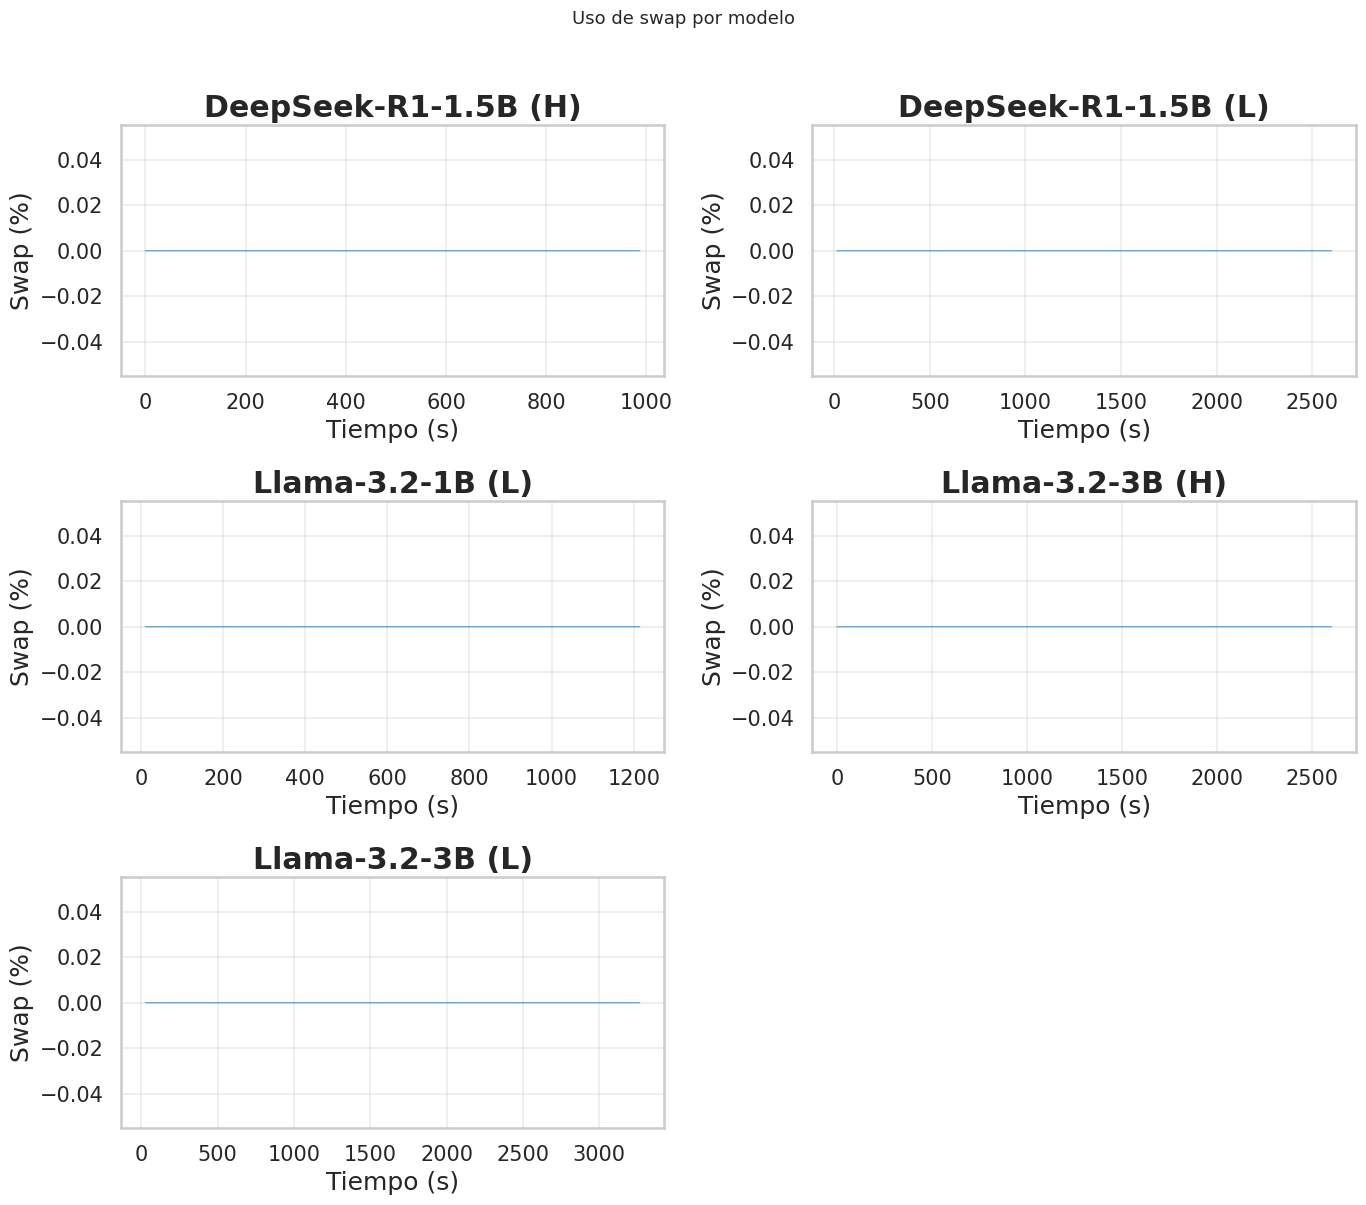

In [10]:
# Swap por modelo (small multiples)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub["swap_pct"].values, alpha=0.6, linewidth=1)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Swap (%)")
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle("Uso de swap por modelo", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para swap")

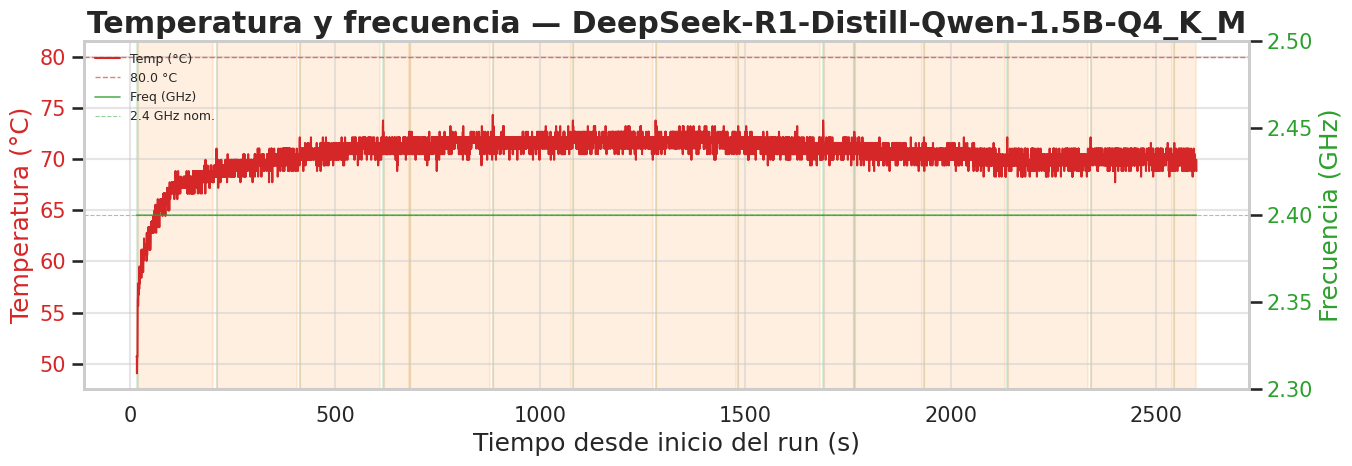

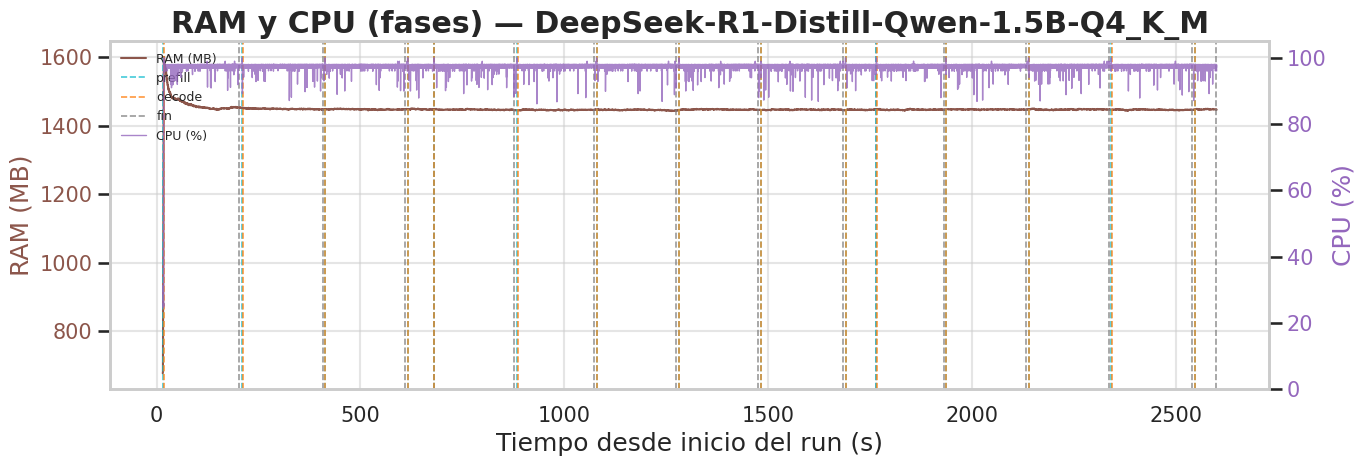

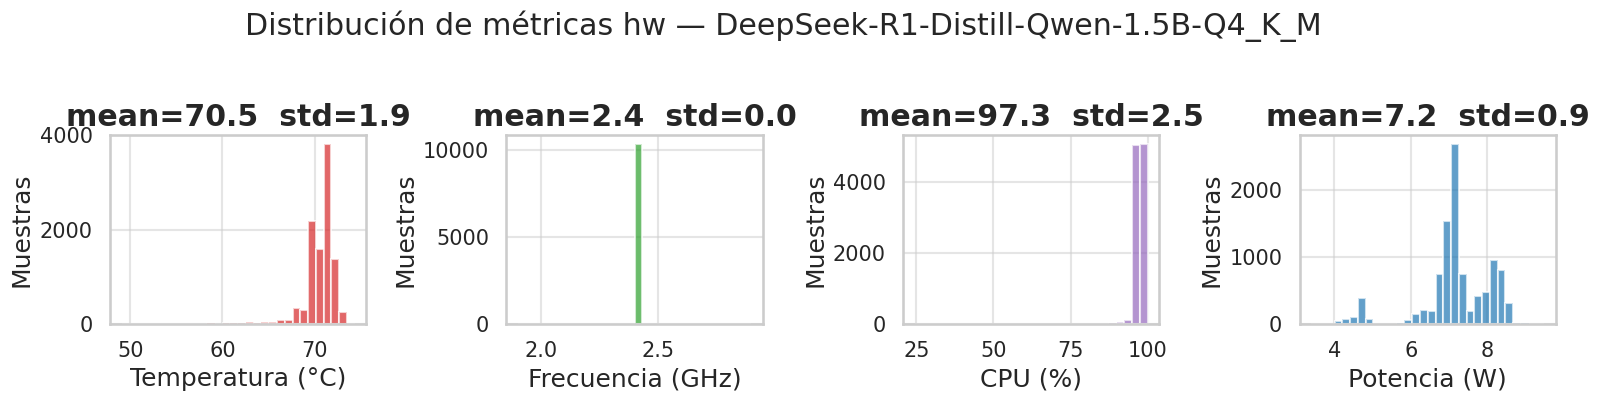

In [11]:
# Análisis detallado de un run representativo (mediana de duración)
from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty and len(ex) > 0:
    run_durations = hw_ex.groupby("run_id")["t_rel_s"].max().sort_values()
    median_idx = len(run_durations) // 2
    representative_run_id = run_durations.index[median_idx]
    representative_run = next((r for r in coll.runs if r.run_id == representative_run_id), None)
    if representative_run:
        hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]
        try:
            fig = temp_freq_dual(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"temp_freq_dual: {e}")
        try:
            fig = cpu_memory_dual_phases(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"cpu_memory_dual_phases: {e}")
        try:
            fig = hw_distributions_panel(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"hw_distributions_panel: {e}")
    else:
        print("No se encontro run representativo")
else:
    print("Sin datos para análisis detallado")

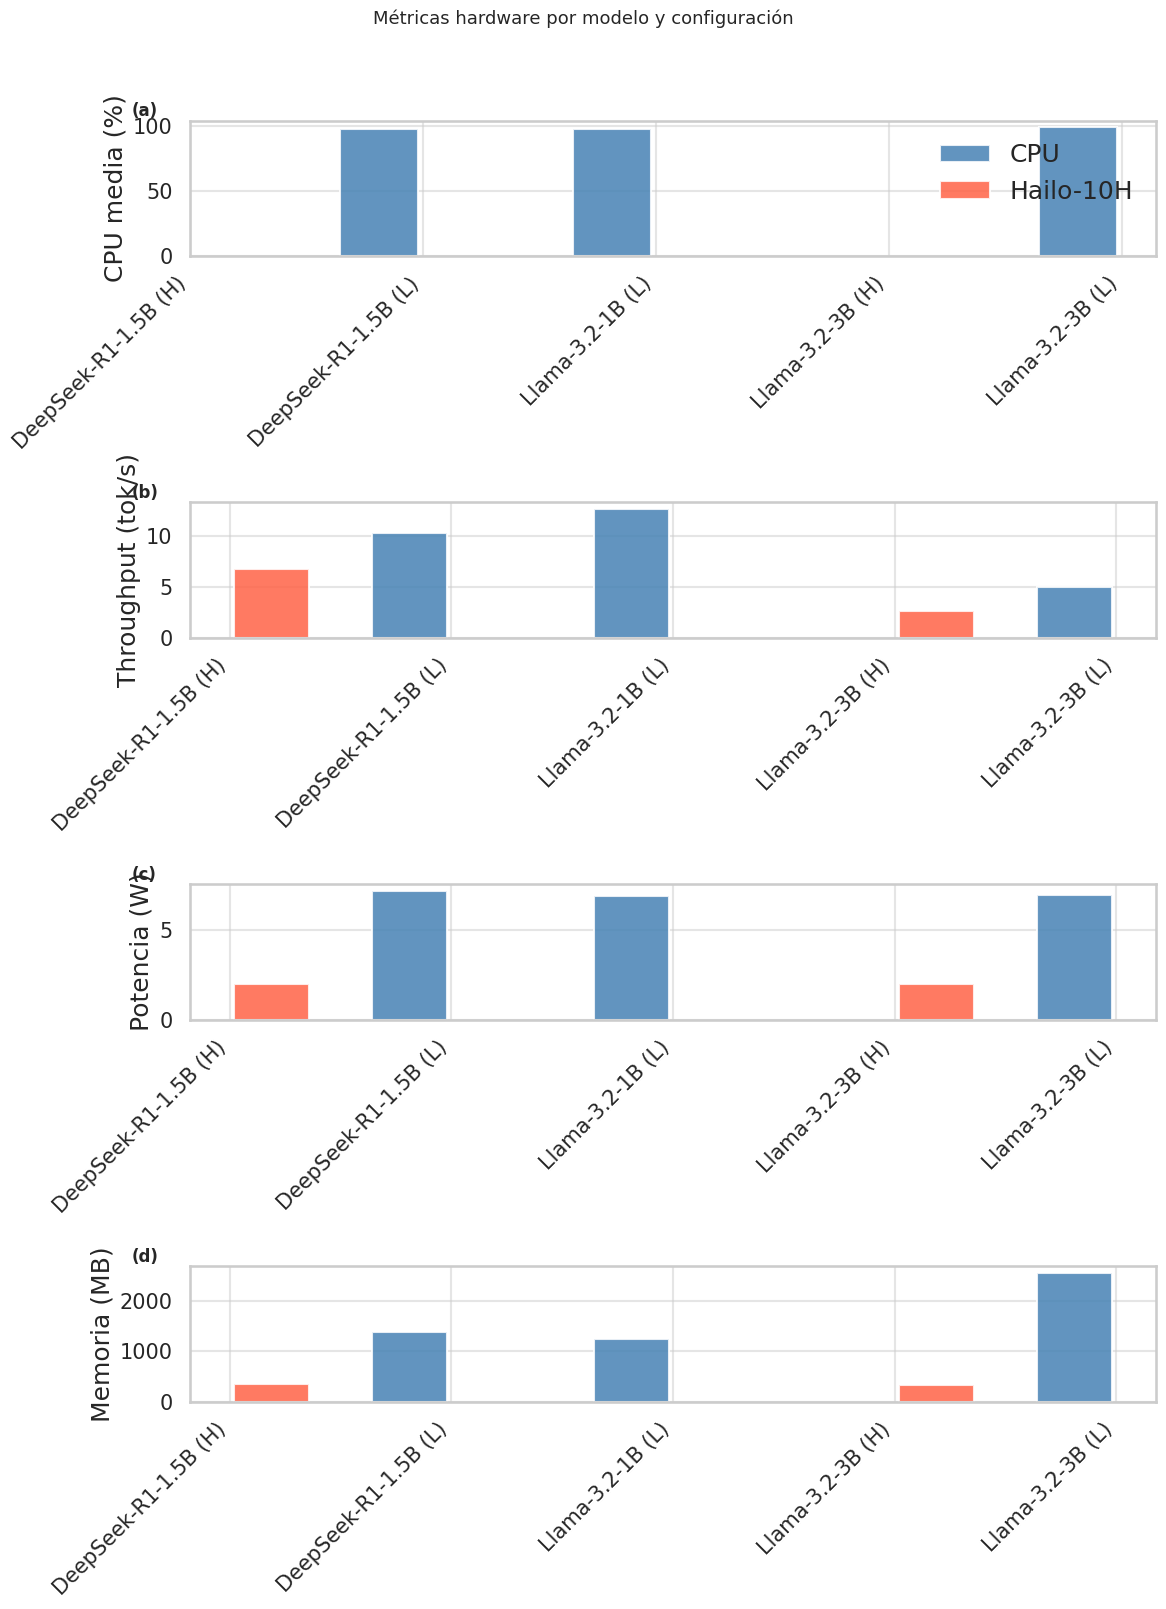

In [12]:
# Grouped bar chart hardware (4 paneles: CPU%, Throughput, Potencia, Memoria)
import re

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

hw_summary_rows = []
pm_valid_tmp = (pm_full[
    (pm_full["run_id"].isin(_run_ids)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
] if "run_id" in pm_full.columns else pd.DataFrame())
for _, row in ex.iterrows():
    if "run_id" not in row.index:
        continue
    hw_r = hw_ex[hw_ex["run_id"] == row["run_id"]] if "run_id" in hw_ex.columns else pd.DataFrame()
    pm_r = pm_valid_tmp[pm_valid_tmp["run_id"] == row["run_id"]] if "run_id" in pm_valid_tmp.columns else pd.DataFrame()
    if hw_r.empty:
        continue
    active_r = hw_r[hw_r["cpu_usage_pct"] > 50]
    group_label = str("Hailo-10H" if row.get("accelerator", False) else "CPU")
    hw_summary_rows.append({
        "model": row["model_label"],
        "config": group_label,
        "cpu_pct": active_r["cpu_usage_pct"].mean() if not active_r.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "power_w": hw_r["internal_power_w"].mean(),
        "mem_mb": hw_r["mem_used_bytes"].mean() / (1024**2) if not hw_r.empty else float("nan"),
    })

if hw_summary_rows:
    hw_summary = pd.DataFrame(hw_summary_rows)
    METRICS = [
        ("cpu_pct",  "CPU media (%)",      "(a)"),
        ("tokens_s", "Throughput (tok/s)", "(b)"),
        ("power_w",  "Potencia (W)",       "(c)"),
        ("mem_mb",   "Memoria (MB)",       "(d)"),
    ]
    models  = sorted(hw_summary["model"].unique())
    configs = sorted(hw_summary["config"].unique())
    x_pos   = np.arange(len(models))
    n_cfg   = len(configs)
    width   = 0.75 / max(n_cfg, 1)
    colors  = ["steelblue", "tomato", "seagreen", "goldenrod"]
    fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 4 * len(METRICS)))
    for i, (ax, (col, ylabel, label)) in enumerate(zip(axes, METRICS)):
        data = hw_summary.dropna(subset=[col])
        for j, (cfg, color) in enumerate(zip(configs, colors)):
            vals = [data[(data["model"] == m) & (data["config"] == cfg)][col].mean()
                    for m in models]
            offset = (j - n_cfg / 2 + 0.5) * width
            ax.bar(x_pos + offset, vals, width * 0.9, label=cfg, color=color, alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.text(-0.06, 1.03, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
        if col == "cpu_pct":
            ax.legend(loc="upper right")
    fig.suptitle("Métricas hardware por modelo y configuración", y=1.01, fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para grouped bar chart hardware")

/tmp/ipykernel_312121/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


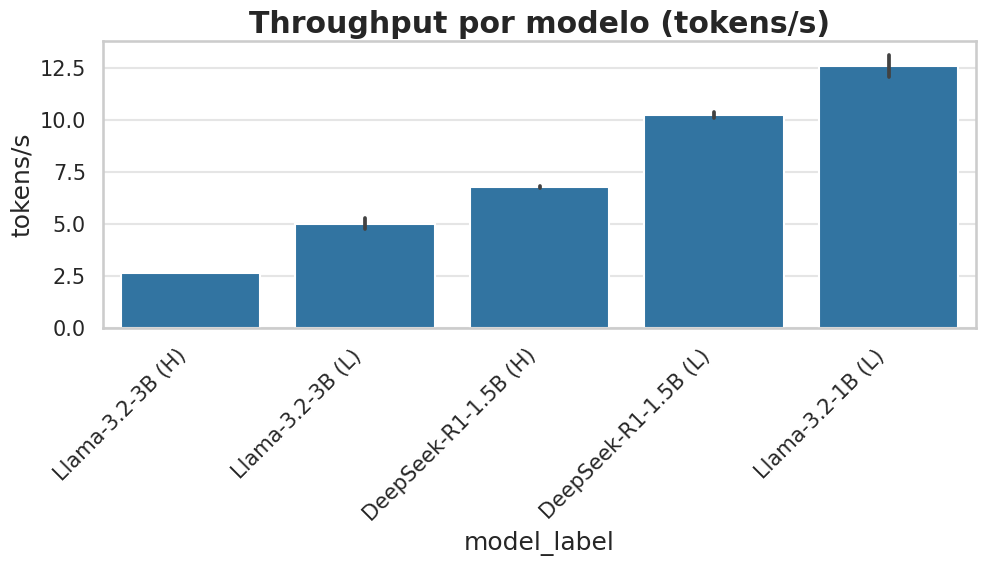

/tmp/ipykernel_312121/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


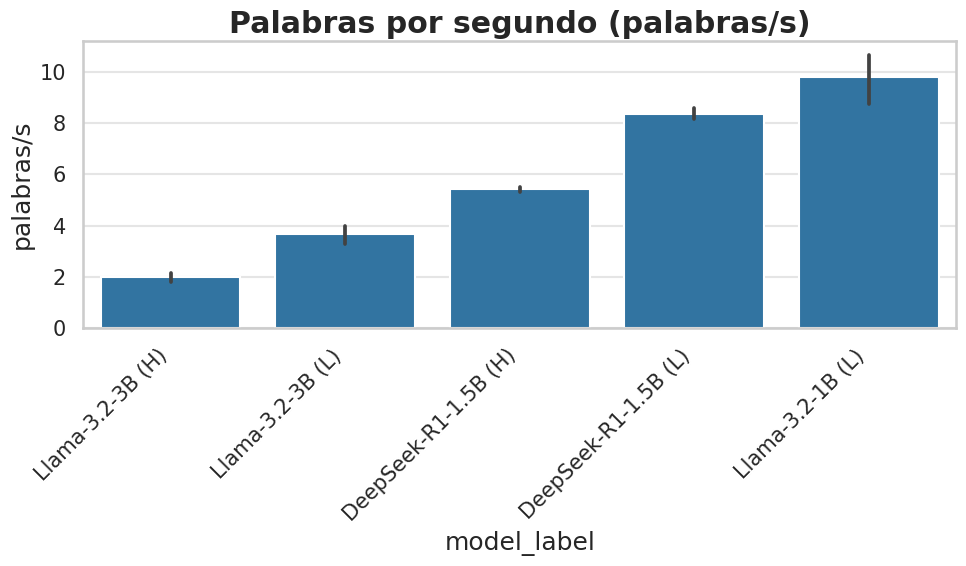

/tmp/ipykernel_312121/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


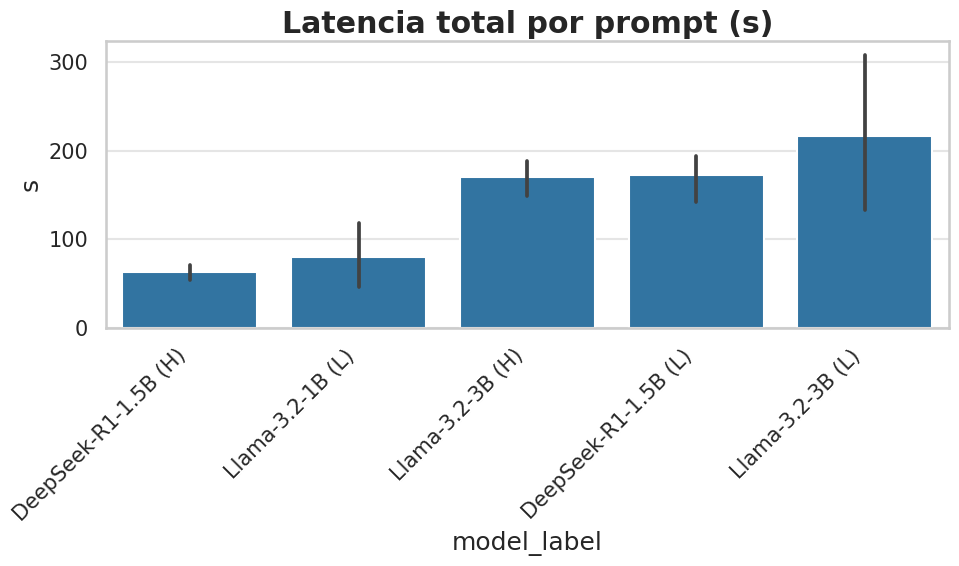

/tmp/ipykernel_312121/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


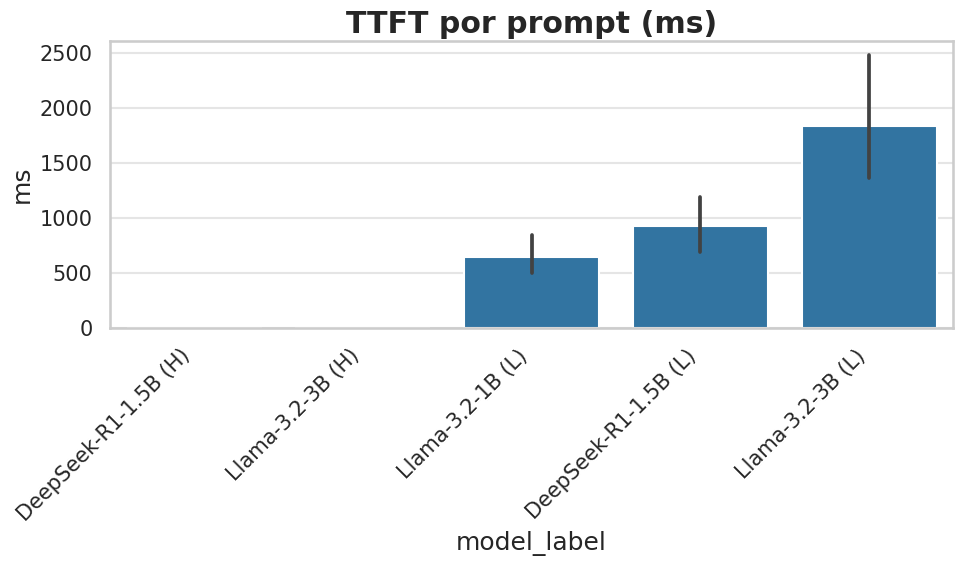

/tmp/ipykernel_312121/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


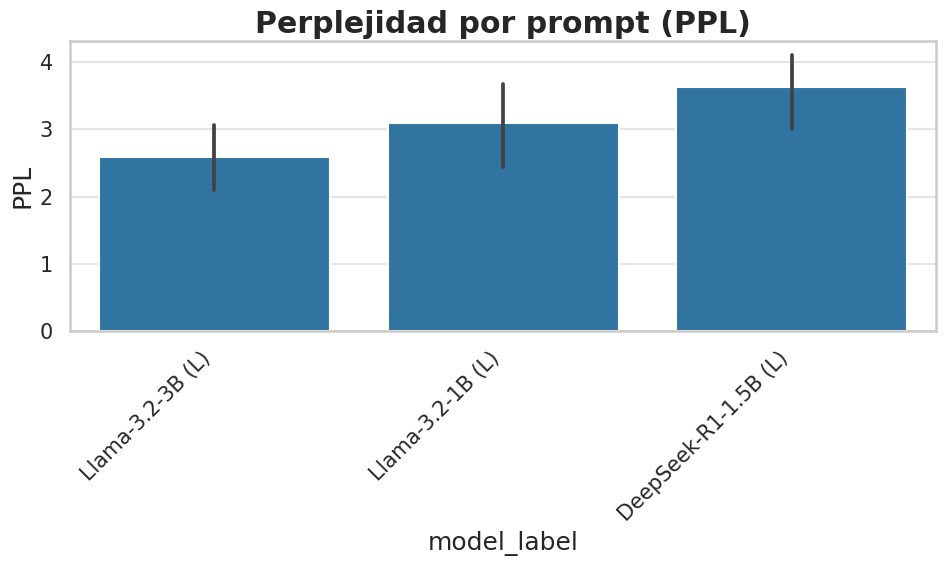

In [13]:
# Métricas de inferencia por modelo
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    _plot_metric(pm_valid, "tokens_per_second", "tokens/s", "Throughput por modelo",
                 unit_label="tokens/s")
    _plot_metric(pm_valid, "words_per_second", "palabras/s", "Palabras por segundo",
                 unit_label="palabras/s")
    _plot_metric(pm_valid, "latency_ms", "ms", "Latencia total por prompt",
                 unit_divisor=1000, unit_label="s")
    _plot_metric(pm_valid, "time_to_first_token_ms", "ms", "TTFT por prompt",
                 unit_label="ms")
    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        _plot_metric(ppl_valid, "perplexity", "", "Perplejidad por prompt",
                     unit_label="PPL")
else:
    print("Sin datos de inferencia")

/tmp/ipykernel_312121/870363815.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


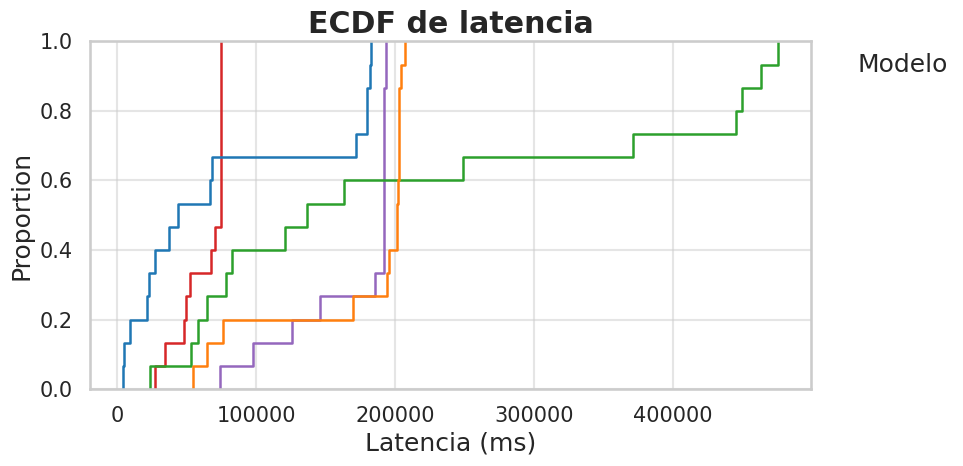

/tmp/ipykernel_312121/870363815.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


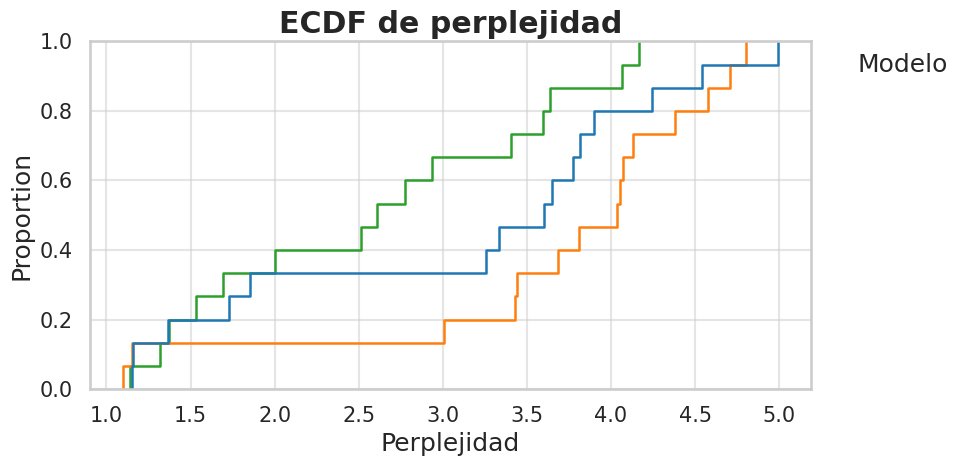

In [14]:
# ECDFs de latencia y perplejidad
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.ecdfplot(data=pm_valid, x="latency_ms", hue="model_label", ax=ax)
    ax.set_title("ECDF de latencia")
    ax.set_xlabel("Latencia (ms)")
    ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    plt.show()

    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.ecdfplot(data=ppl_valid, x="perplexity", hue="model_label", ax=ax)
        ax.set_title("ECDF de perplejidad")
        ax.set_xlabel("Perplejidad")
        ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
else:
    print("Sin datos para ECDFs")

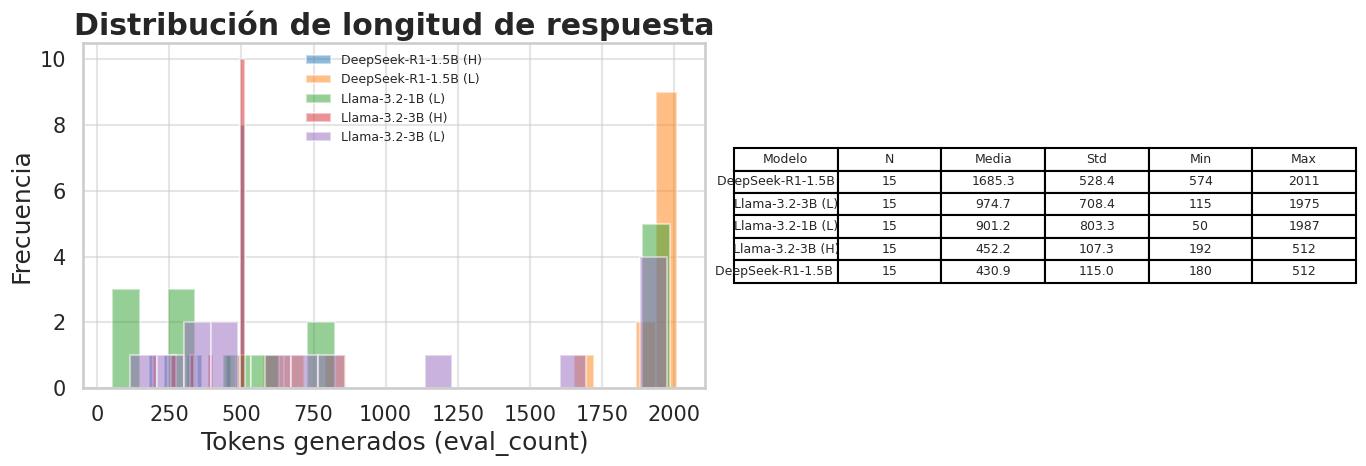

In [15]:
# Distribución de longitud de respuesta
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model in sorted(pm_valid["model_label"].unique()):
        sub = pm_valid[pm_valid["model_label"] == model]
        axes[0].hist(sub["eval_count"], bins=20, alpha=0.5, label=model)
    axes[0].set_xlabel("Tokens generados (eval_count)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de longitud de respuesta")
    axes[0].legend(fontsize=9)
    summary_resp = pm_valid.groupby("model_label")["eval_count"].agg(
        count="count", mean="mean", std="std", min="min", max="max"
    ).round(1).sort_values("mean", ascending=False)
    axes[1].axis("off")
    table_data = [["Modelo", "N", "Media", "Std", "Min", "Max"]]
    for idx, row in summary_resp.iterrows():
        table_data.append([idx, int(row["count"]), f"{row['mean']:.1f}",
                           f"{row['std']:.1f}", f"{row['min']:.0f}", f"{row['max']:.0f}"])
    t = axes[1].table(cellText=table_data, loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(9)
    t.scale(1, 1.5)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para distribución de longitud de respuesta")

In [16]:
# Análisis específico E5: CPU vs Hailo-10H
cpu_data   = ex[ex["accelerator"] == False]
hailo_data = ex[ex["accelerator"] == True]
if not cpu_data.empty and not hailo_data.empty:
    common = sorted(set(cpu_data["model_label"]) & set(hailo_data["model_label"]))
    if common:
        cpu_tps   = [cpu_data[cpu_data["model_label"] == m]["tokens_per_s_mean"].mean() for m in common]
        hailo_tps = [hailo_data[hailo_data["model_label"] == m]["tokens_per_s_mean"].mean() for m in common]
        speedup   = [h / c if c > 0 else float("nan") for c, h in zip(cpu_tps, hailo_tps)]
        x = np.arange(len(common))
        w = 0.35
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].bar(x - w / 2, cpu_tps, w, label="CPU", alpha=0.8)
        axes[0].bar(x + w / 2, hailo_tps, w, label="Hailo-10H", alpha=0.8)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(common, rotation=45, ha='right')
        axes[0].set_ylabel("tokens/s")
        axes[0].set_title("CPU vs Hailo-10H")
        axes[0].legend()
        axes[1].bar(range(len(common)), speedup, alpha=0.8, color="seagreen")
        axes[1].axhline(1.0, ls="--", color="black", alpha=0.5)
        axes[1].set_xticks(range(len(common)))
        axes[1].set_xticklabels(common, rotation=45, ha='right')
        axes[1].set_ylabel("Speedup")
        axes[1].set_title("Aceleración Hailo/CPU")
        fig.tight_layout()
        plt.show()
        display(pd.DataFrame({"Modelo": common, "CPU": cpu_tps, "Hailo": hailo_tps,
                               "Speedup": speedup}).round(2))
        print("NOTA: La potencia del HAT (Hailo Accelerator Tile) no es medible con vcgencmd.")
else:
    print("Sin datos comparables de CPU vs Hailo")

/tmp/ipykernel_312121/1687441584.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


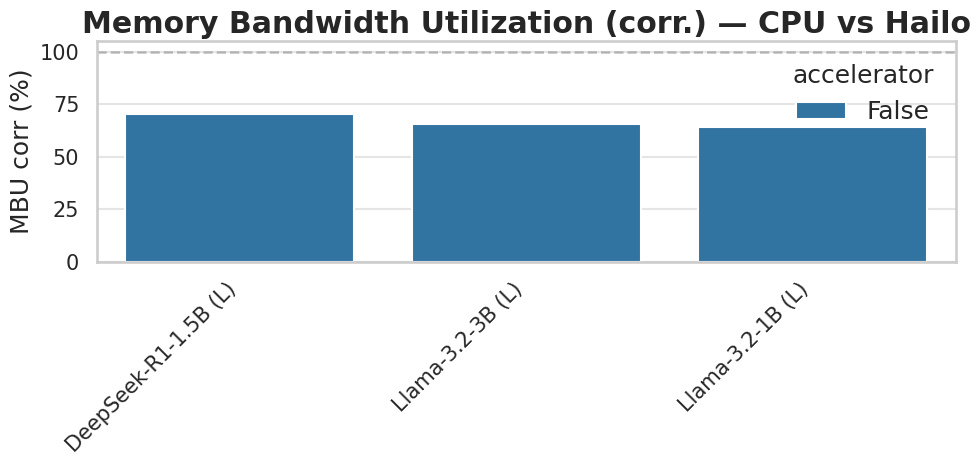

In [17]:
# MBU_corr — Memory Bandwidth Utilization (arquitectura corregida)
from monitorviz.transforms.fom import compute_fom_full

try:
    _mbu_df = compute_fom_full(ex)
    _mbu_col = "mbu_corr"
    if _mbu_col in _mbu_df.columns and _mbu_df[_mbu_col].notna().any():
        _mbu_d = _mbu_df.dropna(subset=[_mbu_col])
        _acc_col = "accelerator" if "accelerator" in _mbu_d.columns else None
        _hue_mbu = _acc_col

        fig, ax = plt.subplots(figsize=(10, 5))
        _order = (_mbu_d.groupby("model_label")[_mbu_col]
                  .mean().sort_values(ascending=False).index)
        kw = dict(data=_mbu_d, x="model_label", y=_mbu_col, order=_order, ax=ax)
        if _hue_mbu and _hue_mbu in _mbu_d.columns:
            kw["hue"] = _hue_mbu
        sns.barplot(**kw)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_ylabel("MBU corr (%)")
        ax.set_xlabel("")
        ax.set_title("Memory Bandwidth Utilization (corr.) — CPU vs Hailo")
        ax.axhline(100, ls="--", color="gray", alpha=0.5)
        fig.tight_layout()
        plt.show()
    else:
        print("Sin columna mbu_corr")
except Exception as e:
    print(f"Error en MBU: {e}")


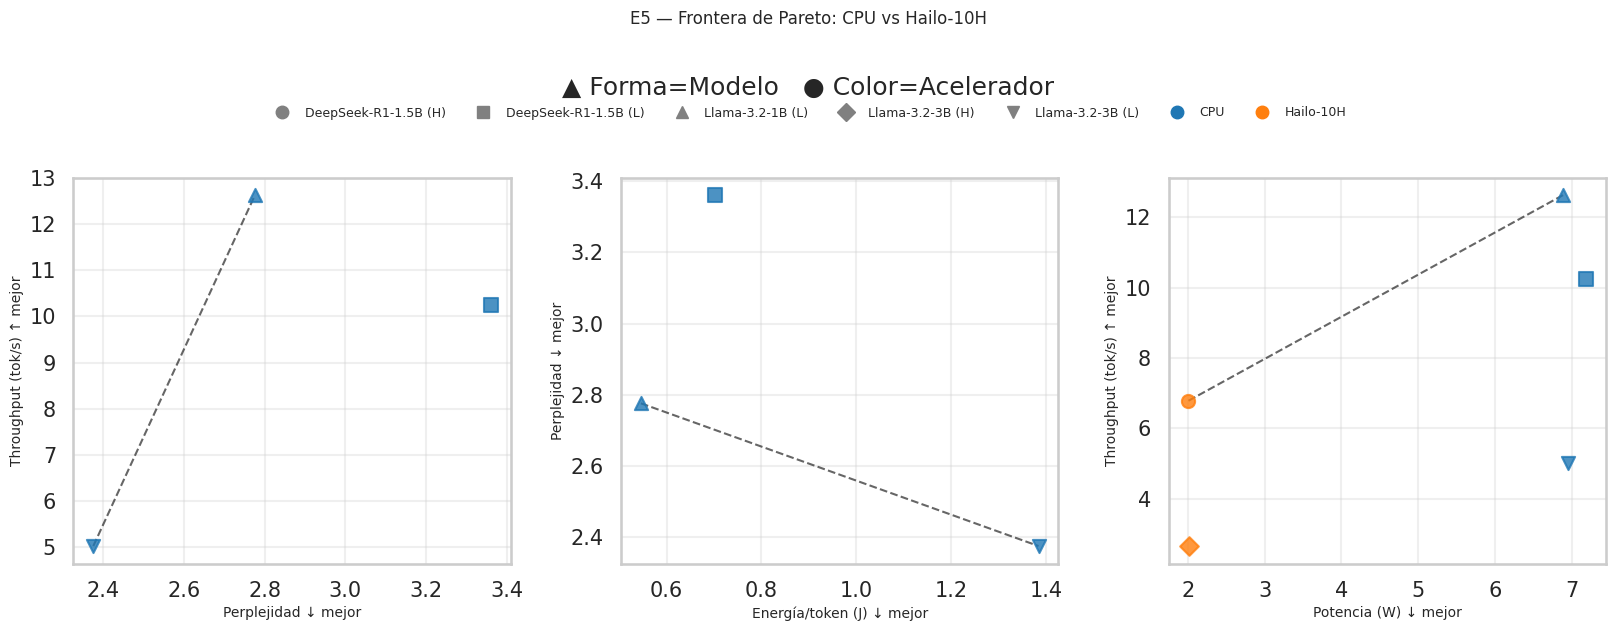

In [18]:
# Trade-offs multidimensionales — Frontera de Pareto (E5)
# Formas = modelo, colores = accelerator (CPU vs Hailo), leyenda fuera
from matplotlib.lines import Line2D as _L2D

def _pmask5(df, x_col, y_col, x_low, y_low):
    pts = df[[x_col, y_col]].to_numpy(dtype=float)
    dom = np.zeros(len(pts), dtype=bool)
    for i in range(len(pts)):
        for j in range(len(pts)):
            if i == j: continue
            xb = (pts[j,0] <= pts[i,0]) if x_low else (pts[j,0] >= pts[i,0])
            yb = (pts[j,1] <= pts[i,1]) if y_low else (pts[j,1] >= pts[i,1])
            if xb and yb and (pts[j,0] != pts[i,0] or pts[j,1] != pts[i,1]):
                dom[i] = True; break
    return ~dom

_pareto_pairs5 = [
    ("perplexity_geomean", "tokens_per_s_mean",  True,  False, "Perplejidad",       "Throughput (tok/s)"),
    ("energy_per_token_j", "perplexity_geomean",  True,  True,  "Energía/token (J)", "Perplejidad"),
    ("power_mean_w",       "tokens_per_s_mean",   True,  False, "Potencia (W)",      "Throughput (tok/s)"),
]
valid_pairs5 = [(xc,yc,xl,yl,xlab,ylab) for xc,yc,xl,yl,xlab,ylab in _pareto_pairs5
                if xc in ex.columns and yc in ex.columns]

if valid_pairs5 and not ex.empty:
    _models5  = sorted(ex["model_label"].unique())
    _MK5      = ["o","s","^","D","v","P","X"]
    _MOD_MK5  = {m: _MK5[i % len(_MK5)] for i, m in enumerate(_models5)}

    # Accelerator as subtype color
    _accs5    = sorted(ex["accelerator"].dropna().unique()) if "accelerator" in ex.columns else []
    _ACC_LABEL = {True: "Hailo-10H", False: "CPU"}
    _ACC_COL   = {True: "tab:orange", False: "tab:blue"}

    nc5 = len(valid_pairs5)
    fig, axes = plt.subplots(1, nc5, figsize=(nc5 * 5.5, 5.5))
    if nc5 == 1: axes = [axes]

    for ax, (xc, yc, xl, yl, xlabel, ylabel) in zip(axes, valid_pairs5):
        df_p = ex.dropna(subset=[xc, yc]).reset_index(drop=True)
        if df_p.empty: ax.set_visible(False); continue

        for model in _models5:
            for acc in _accs5:
                _sub = df_p[(df_p["model_label"]==model) & (df_p["accelerator"]==acc)]
                if _sub.empty: continue
                ax.scatter(_sub[xc], _sub[yc],
                           marker=_MOD_MK5[model],
                           color=_ACC_COL.get(acc, "tab:gray"),
                           s=90, alpha=0.8, zorder=3)

        mask = _pmask5(df_p, xc, yc, xl, yl)
        df_front = df_p[mask].sort_values(xc)
        if not df_front.empty:
            ax.plot(df_front[xc], df_front[yc], "k--", lw=1.5, alpha=0.6)

        ax.set_xlabel(xlabel + (" ↓ mejor" if xl else " ↑ mejor"), fontsize=10)
        ax.set_ylabel(ylabel + (" ↓ mejor" if yl else " ↑ mejor"), fontsize=10)
        ax.grid(True, alpha=0.3)

    _mod_h5 = [_L2D([],[],marker=_MOD_MK5[m],color="gray",ls="none",ms=9,label=m) for m in _models5]
    _acc_h5 = [_L2D([],[],marker="o",color=_ACC_COL.get(a,"tab:gray"),ls="none",ms=9,
                    label=_ACC_LABEL.get(a,str(a))) for a in _accs5]
    fig.legend(
        handles=_mod_h5 + _acc_h5,
        loc="upper center", bbox_to_anchor=(0.5, 1.06),
        ncol=min(len(_models5) + len(_accs5), 7), fontsize=9,
        title="▲ Forma=Modelo   ● Color=Acelerador"
    )
    fig.suptitle("E5 — Frontera de Pareto: CPU vs Hailo-10H", fontsize=12, y=1.16)
    fig.tight_layout()
    plt.show()
else:
    print("Columnas insuficientes para Pareto o sin datos E5")


In [19]:
# Desglose de fases (si hay datos)
try:
    from monitorviz.viz import phase_breakdown_stacked
    _run_ids_15 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    pm_valid = (pm_full[
        (pm_full["run_id"].isin(_run_ids_15)) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ] if "run_id" in pm_full.columns else pd.DataFrame())
    if not pm_valid.empty and "phase_prompt_s" in pm_valid.columns:
        fig = phase_breakdown_stacked(ex, normalized=True)
        plt.show()
        fig = phase_breakdown_stacked(ex, normalized=False)
        plt.show()
    else:
        print("Sin datos de fases")
except Exception as e:
    print(f"Error en phase_breakdown: {e}")

Sin datos de fases


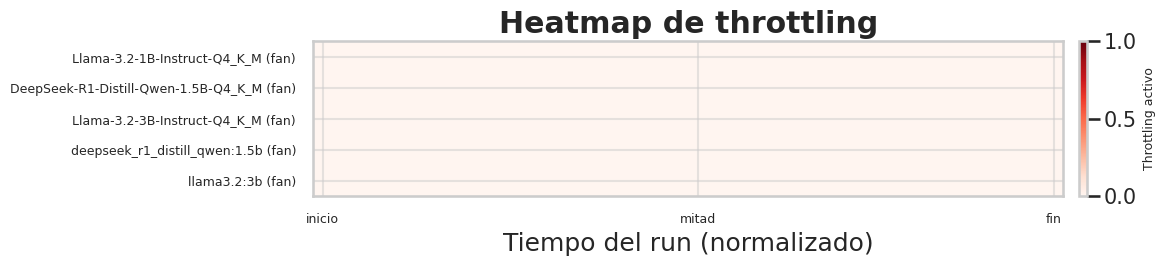

In [20]:
# Throttling heatmap
try:
    from monitorviz.viz import throttling_heatmap
    _run_ids_16 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    hw_ex = hw_full[hw_full["run_id"].isin(_run_ids_16)] if "run_id" in hw_full.columns else pd.DataFrame()
    runs_ex = [r for r in coll.runs if r.run_id in _run_ids_16]
    if hw_ex.empty or not runs_ex:
        print("Sin datos de hardware para heatmap de throttling")
    else:
        fig = throttling_heatmap(hw_ex, runs_ex, bins=40,
                                 title="Heatmap de throttling")
        plt.show()
except Exception as e:
    print(f"Error en throttling_heatmap: {e}")

## Eficiencia computacional: trabajo CPU efectivo

- **W_CPU (core·s)**: integra `(f(t)/f_nom) x (CPU(t)/100) x N_cores x dt`
- **eta_CPU**: W_CPU / (N_cores x T), rango [0,1]
- **W_token (core·s/token)**: trabajo CPU por token generado

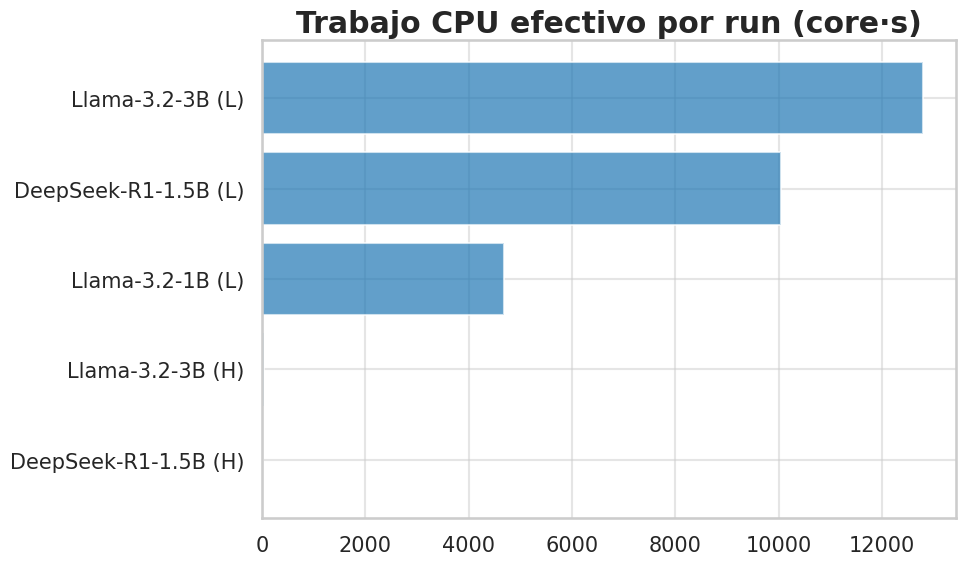

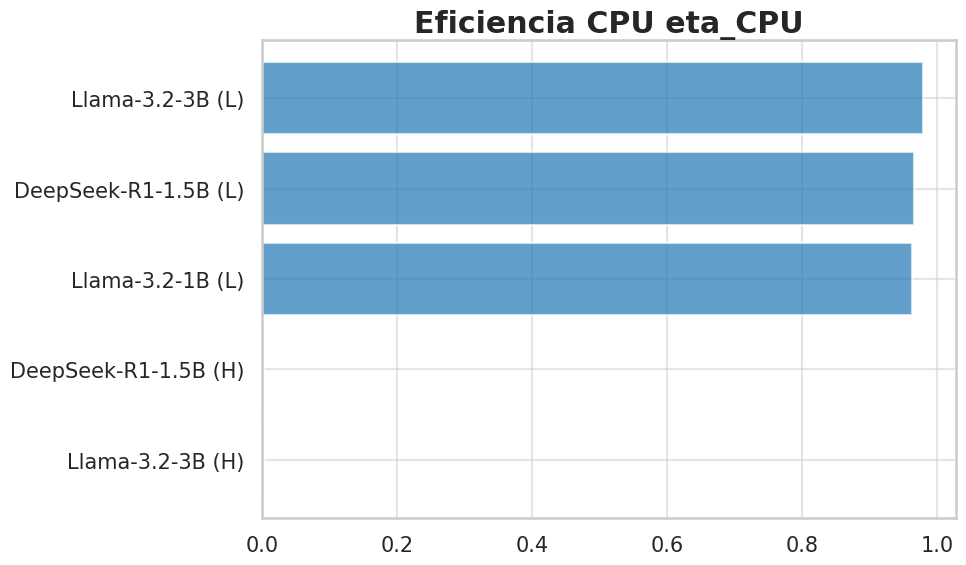

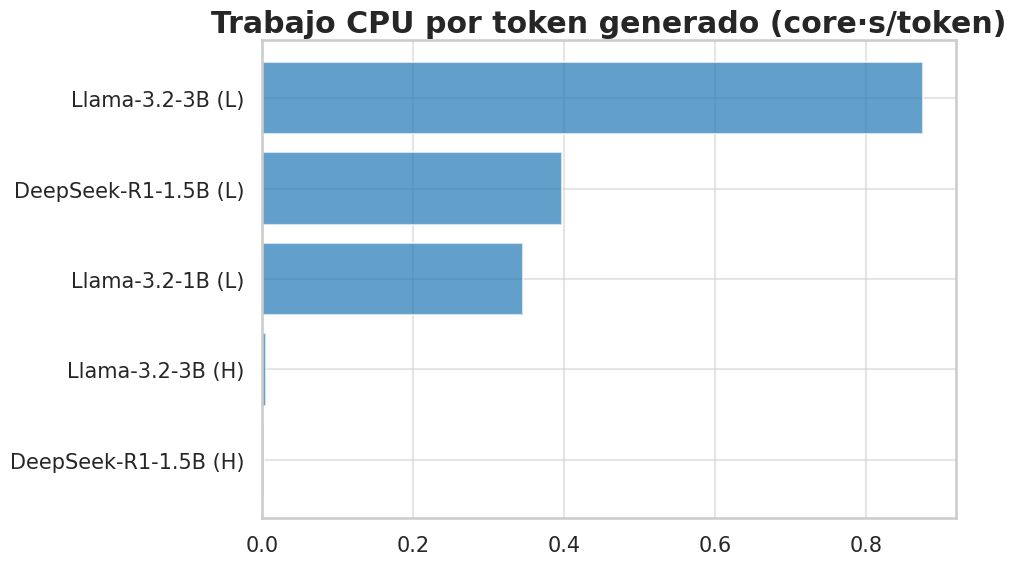

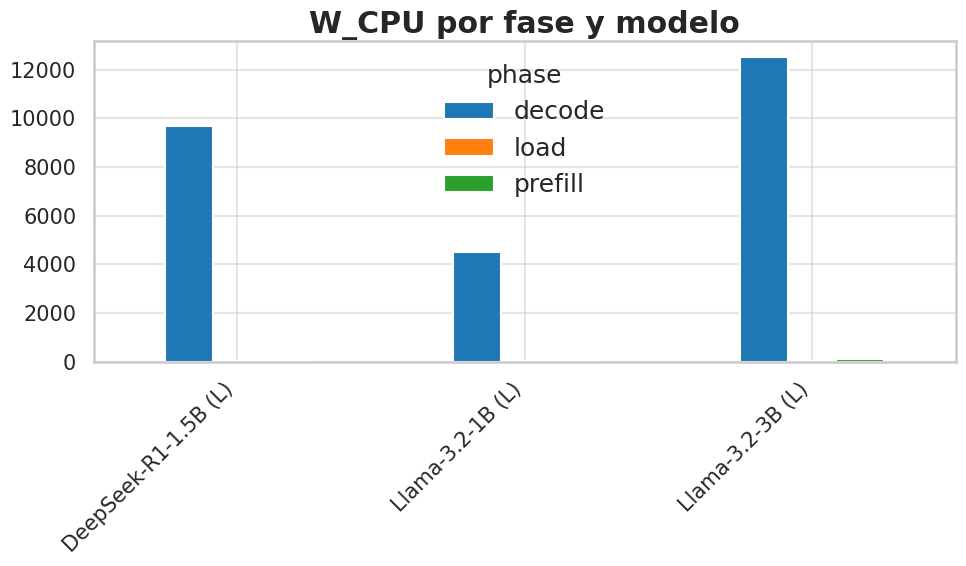

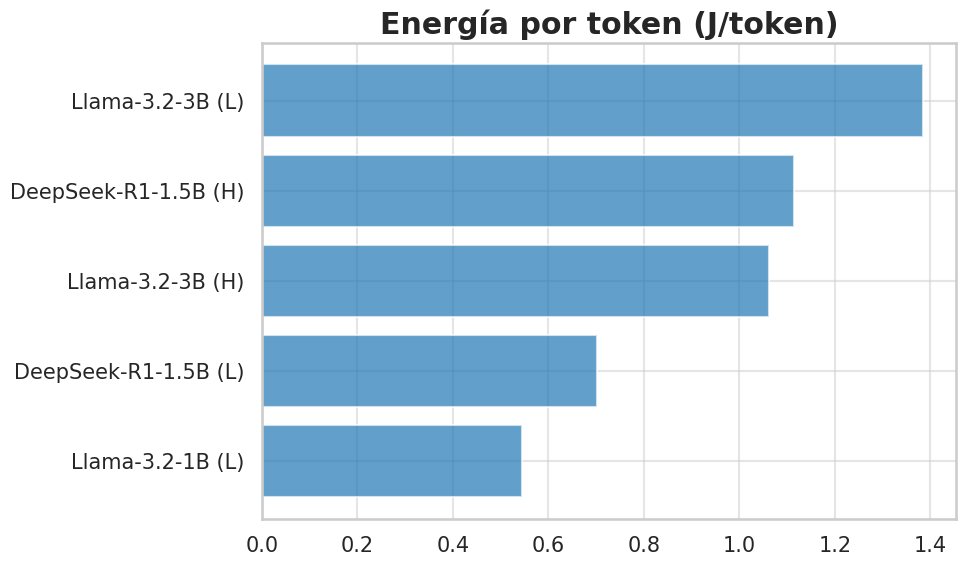

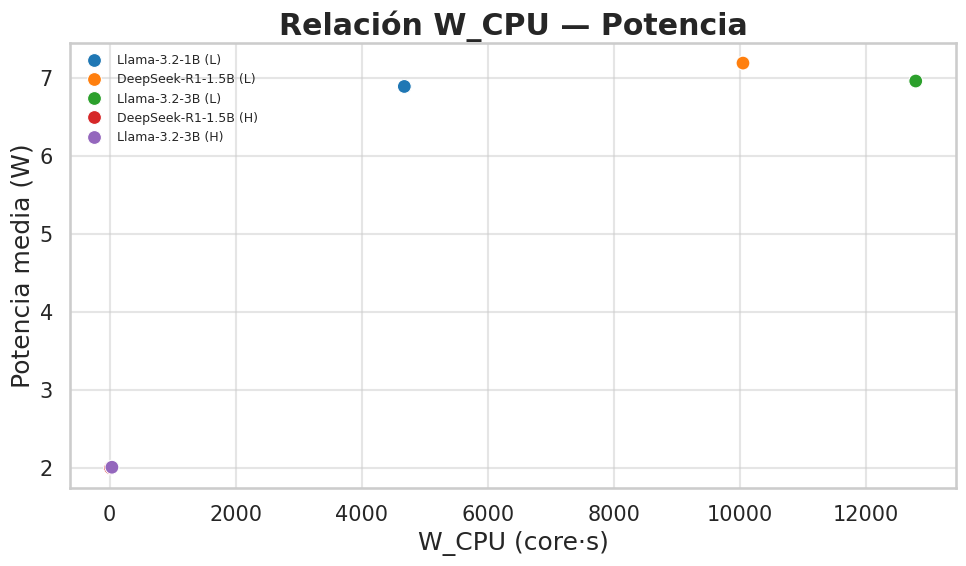

In [21]:
# Eficiencia computacional y energética
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

for col, ylabel, title in [
    ("cpu_work_core_s", "core·s", "Trabajo CPU efectivo por run"),
    ("cpu_efficiency",  "",       "Eficiencia CPU eta_CPU"),
    ("cpu_work_per_token", "core·s/token", "Trabajo CPU por token generado"),
]:
    if col in ex.columns:
        _plot_metric(ex, col, ylabel=ylabel, title=title, unit_label=ylabel)

# Desglose por fases
try:
    phase_df = coll.cpu_work_by_phase_df() if hasattr(coll, "cpu_work_by_phase_df") else pd.DataFrame()
    phase_df_ex = phase_df[phase_df["run_id"].isin(ex["run_id"])] if not phase_df.empty else pd.DataFrame()
    if not phase_df_ex.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        phase_df_ex.groupby(["model_label", "phase"])["cpu_work_core_s"].mean().unstack().plot(
            kind="bar", ax=ax, rot=45)
        ax.set_title("W_CPU por fase y modelo")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        fig.tight_layout()
        plt.show()
except Exception as e:
    print(f"cpu_work_by_phase_df: {e}")

# Energía por token
if "energy_per_token_j" in ex.columns:
    _plot_metric(ex, "energy_per_token_j", "J/token", "Energía por token", unit_label="J/token")

# Scatterplot CPU vs Potencia
if "cpu_work_core_s" in ex.columns and "power_mean_w" in ex.columns:
    valid_data = ex.dropna(subset=["cpu_work_core_s", "power_mean_w"])
    if not valid_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=valid_data, x="cpu_work_core_s", y="power_mean_w",
                        hue="model_label", s=100, ax=ax)
        ax.set_xlabel("W_CPU (core·s)")
        ax.set_ylabel("Potencia media (W)")
        ax.set_title("Relación W_CPU — Potencia")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

In [22]:
# E4/E5: Seccion 18 — sin scatter arquitectura especifico
print("Seccion 18: no aplica análisis de arquitectura especifico para este experimento.")

Seccion 18: no aplica análisis de arquitectura especifico para este experimento.


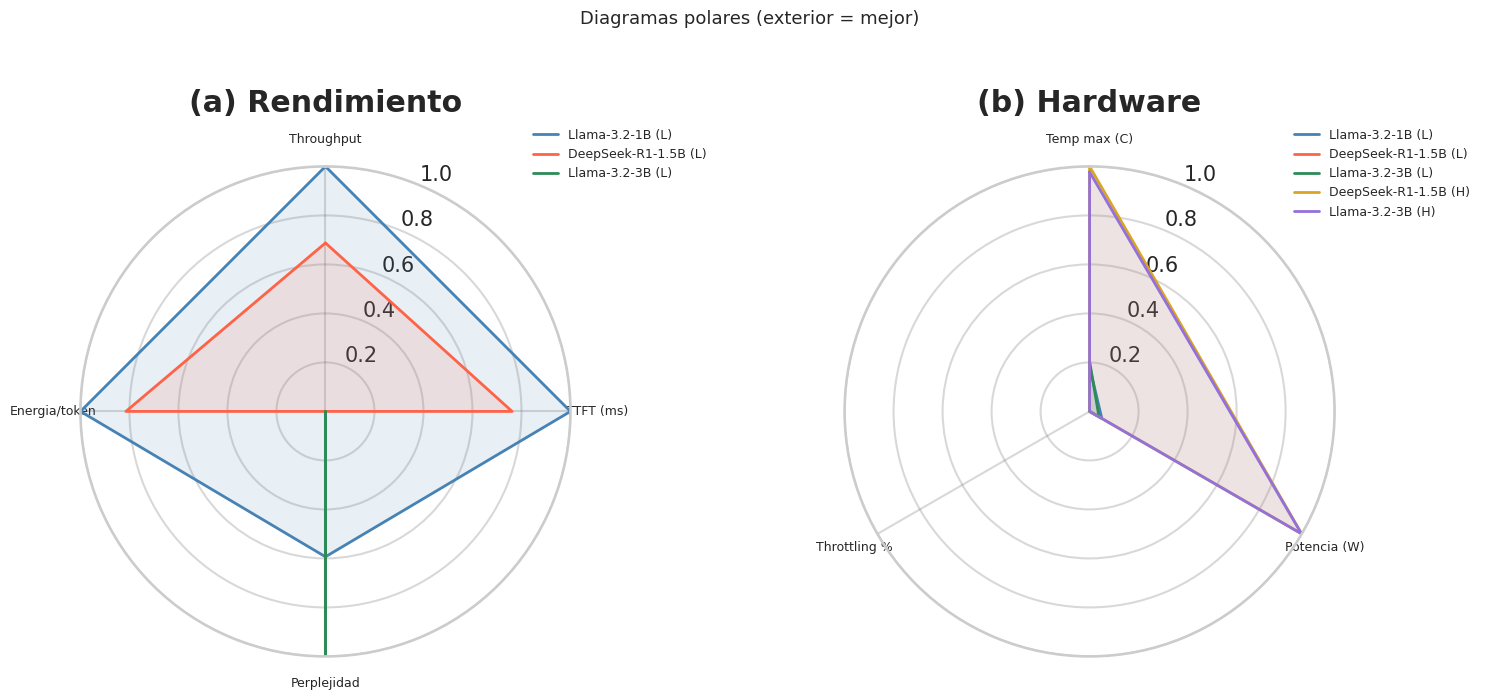

In [23]:
# Diagramas polares (rendimiento y hardware)
def _radar_chart(df, metrics, title, ax, colors):
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        return
    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontweight="bold")
    for (_, row), color in zip(data.iterrows(), colors[:len(data)]):
        vals = []
        for col, _, higher_is_better in metrics:
            col_min, col_max = data[col].min(), data[col].max()
            rng = col_max - col_min if col_max != col_min else 1.0
            vals.append((data.loc[row.name, col] - col_min) / rng if higher_is_better
                        else (col_max - data.loc[row.name, col]) / rng)
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row["model_label"])
        ax.fill(angles, vals, alpha=0.12, color=color)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

perf_metrics = [
    ("tokens_per_s_mean",  "Throughput",      True),
    ("ttft_ms_mean",       "TTFT (ms)",        False),
    ("perplexity_geomean", "Perplejidad",      False),
    ("energy_per_token_j", "Energia/token",    False),
]
hw_metrics_radar = [
    ("temp_max_c",      "Temp max (C)", False),
    ("power_mean_w",    "Potencia (W)", False),
    ("throttled_ratio", "Throttling %", False),
]
colors_radar = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple", "coral", "slategray"]
fig = plt.figure(figsize=(16, 7))
perf_avail = [m for m in perf_metrics if m[0] in ex.columns]
hw_avail   = [m for m in hw_metrics_radar if m[0] in ex.columns]
if perf_avail:
    ax1 = fig.add_subplot(121, polar=True)
    _radar_chart(ex, perf_avail, "(a) Rendimiento", ax1, colors_radar)
if hw_avail:
    ax2 = fig.add_subplot(122, polar=True)
    _radar_chart(ex, hw_avail, "(b) Hardware", ax2, colors_radar)
fig.suptitle("Diagramas polares (exterior = mejor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

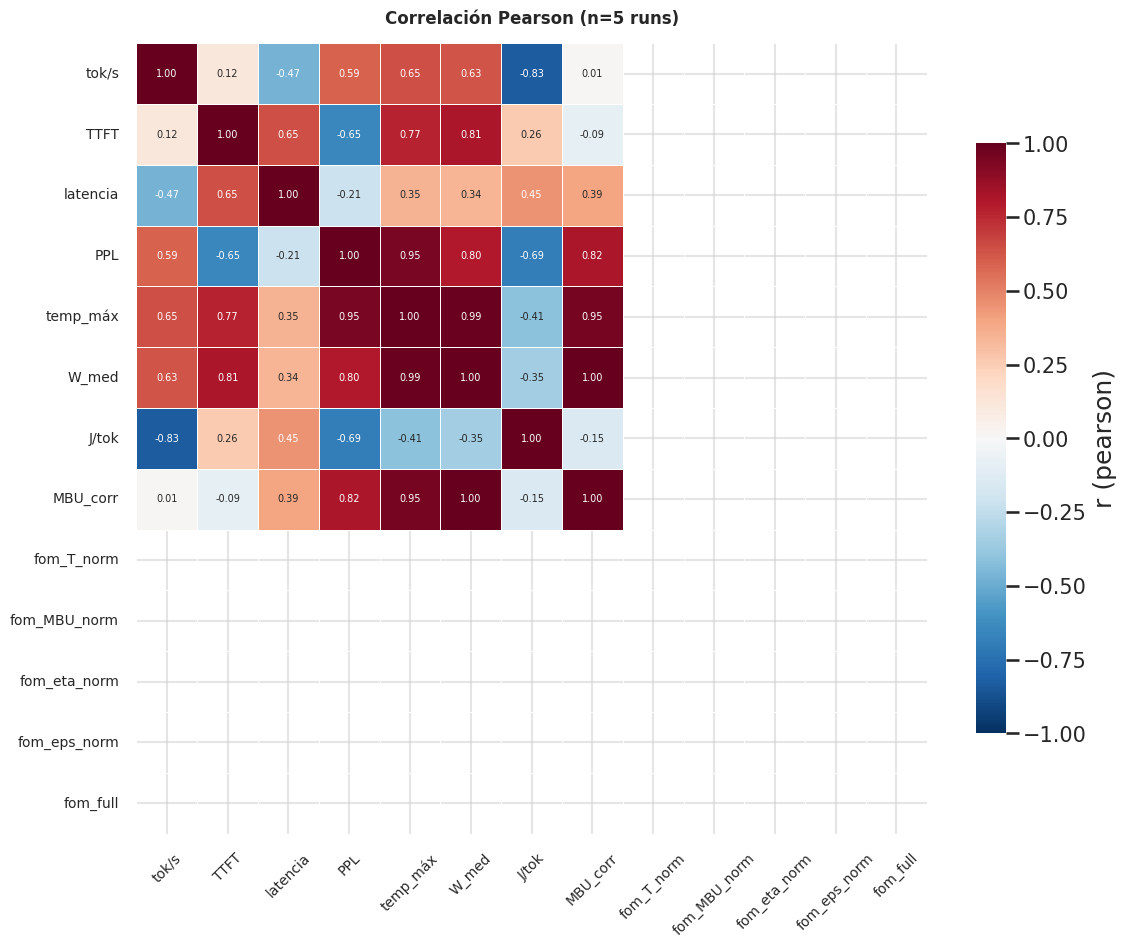

In [24]:
# Correlación de Pearson
try:
    from monitorviz.viz import correlation_heatmap
    from monitorviz.transforms.fom import compute_fom_full
    if len(ex) >= 3:
        _fom_p5 = compute_fom_full(ex)
        _pearson_cols5 = [c for c in [
            "tokens_per_s_mean", "ttft_ms_mean", "latency_ms_mean",
            "perplexity_geomean", "temp_max_c", "power_mean_w",
            "energy_per_token_j", "mbu_corr",
            "fom_T_norm", "fom_MBU_norm", "fom_eta_norm", "fom_eps_norm", "fom_full",
        ] if c in _fom_p5.columns]
        fig = correlation_heatmap(_fom_p5, cols=_pearson_cols5,
                                  title=f"Correlación Pearson (n={len(_fom_p5)} runs)")
        plt.show()
    else:
        print(f"Datos insuficientes: {len(ex)} run(s), se necesitan >=3.")
except Exception as e:
    print(f"Error en correlación: {e}")


In [25]:
# Alertas y anomalías
alerts = []
if "throttled_ratio" in ex.columns:
    for _, row in ex[ex["throttled_ratio"] > 0.5].iterrows():
        alerts.append(f"throttling: {row['model_label']} ({row['throttled_ratio']*100:.1f}%)")
if "n_empty_generations" in ex.columns:
    for _, row in ex[ex["n_empty_generations"] > 0].iterrows():
        alerts.append(f"generaciones vacias: {row['model_label']} (n={int(row['n_empty_generations'])})")
if "tokens_per_s_mean" in ex.columns and len(ex) >= 3:
    mean_tps = ex["tokens_per_s_mean"].mean()
    std_tps  = ex["tokens_per_s_mean"].std()
    for _, row in ex[(ex["tokens_per_s_mean"] > mean_tps + 2 * std_tps) |
                     (ex["tokens_per_s_mean"] < mean_tps - 2 * std_tps)].iterrows():
        alerts.append(f"outlier throughput: {row['model_label']} ({row['tokens_per_s_mean']:.2f} tok/s)")
for a in alerts:
    print(f"ALERTA: {a}")
if not alerts:
    print("Sin alertas detectadas")

Sin alertas detectadas


## Conclusiones y discusión

### Confirmación/refutación de hipótesis
> TODO

### Hallazgos principales
> TODO

### Limitaciones
> TODO